# Assignment 1 - 46770 Integrated Energy Grids  
February 2026

In this first part of the course project, you are asked to carry out the tasks described below.

Write a short report (maximum length 6 pages) in groups of 4 students, including your main findings, and upload it to DTULearn.

Deadline for submission: March 25, 2026, 23:55


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import pypsa
import requests
import re
import math
import numpy as np

## Adding the data and cleaning
**Getting the Data Paths**

In [2]:
BASE_DIR = Path.cwd()  
DATA_DIR = BASE_DIR.parent / "data"
PLOTS_DIR = BASE_DIR.parent / "Plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

GENERATION_FILE = DATA_DIR / "energy-charts_Total_net_electricity_generation_in_Germany_in_2024.csv"
LOAD_FILE = DATA_DIR / "energy-charts_Total_net_electricity_generation_in_Germany_in_2024_load.csv"

**Read files + fixing column names**

In [3]:
print("Reading files...")
print("Generation file:", GENERATION_FILE)
print("Load file:", LOAD_FILE)

# Extracting the raw column names to understand the structure of the data
gen_raw = pd.read_csv(GENERATION_FILE)
load_raw = pd.read_csv(LOAD_FILE)

# Getting the column names and stripping (taking out) any leading/trailing whitespaces
gen_raw.columns = [str(c).strip() for c in gen_raw.columns]
load_raw.columns = [str(c).strip() for c in load_raw.columns]

print("\nGeneration columns:")
print(gen_raw.columns.tolist())

print("\nLoad columns:")
print(load_raw.columns.tolist())

# _____________________________________________________________________
# Fixing column names
GENERATION_TIME_COL = gen_raw.columns[0]
LOAD_TIME_COL = load_raw.columns[0]

# generation file expected columns
WIND_OFFSHORE_COL = "Wind offshore"
WIND_ONSHORE_COL = "Wind onshore"
SOLAR_COL = "Solar"  # IMPORTANT!: The historical solar generation data used in the model is aggregated and does not distinguish between rooftop and utility-scale PV.

# load file expected column
LOAD_COL = "Load"

Reading files...
Generation file: c:\Users\Fernando\OneDrive - Danmarks Tekniske Universitet\Escritorio\MscSustainableEnergy\4 Semester\46770 Integrated Energy Grids\Assignment\Integrated_Energy_Grids\data\energy-charts_Total_net_electricity_generation_in_Germany_in_2024.csv
Load file: c:\Users\Fernando\OneDrive - Danmarks Tekniske Universitet\Escritorio\MscSustainableEnergy\4 Semester\46770 Integrated Energy Grids\Assignment\Integrated_Energy_Grids\data\energy-charts_Total_net_electricity_generation_in_Germany_in_2024_load.csv

Generation columns:
['Date (GMT+1)', 'Wind offshore', 'Wind onshore', 'Solar']

Load columns:
['Date (GMT+1)', 'Load']


**Parsing dates**

In [4]:
def parse_time(series):
    # Turn data col into date time format
    try:
        return pd.to_datetime(series, errors="coerce", utc=True, format="mixed")
    except Exception:
        return pd.to_datetime(series, errors="coerce", utc=True)

gen_raw[GENERATION_TIME_COL] = parse_time(gen_raw[GENERATION_TIME_COL])
load_raw[LOAD_TIME_COL] = parse_time(load_raw[LOAD_TIME_COL])

gen_raw = gen_raw.dropna(subset=[GENERATION_TIME_COL]).copy()
load_raw = load_raw.dropna(subset=[LOAD_TIME_COL]).copy()

gen_raw = gen_raw.set_index(GENERATION_TIME_COL)
load_raw = load_raw.set_index(LOAD_TIME_COL)

# If the time index of both load and generation files has timezone information:
# - First convert it to the "Europe/Berlin" timezone, which corresponds to the local
#   German electricity system time used in the datasets.
# - Then remove the timezone information (tz_localize(None)) to obtain a naive
#   datetime index.
#
# This ensures that:
# - The timestamps remain aligned with the German calendar year.
# - We avoid shifts caused by converting to UTC (which could move the first hour
#   of the year to the previous day).
# - The time index is easier to work with in PyPSA and pandas operations.
if getattr(gen_raw.index, "tz", None) is not None:
    gen_raw.index = gen_raw.index.tz_convert("Europe/Berlin").tz_localize(None)
    gen_raw.index.name = "Date"

if getattr(load_raw.index, "tz", None) is not None:
    load_raw.index = load_raw.index.tz_convert("Europe/Berlin").tz_localize(None)
    load_raw.index.name = "Date"

**Data cleaning**

In [5]:
def parse_number(series):
    # Turn data col into numeric format, removing any non-numeric characters (like spaces, commas, etc.)
    s = series.astype(str).str.strip()
    s = s.str.replace("\u202f", "", regex=False)
    s = s.str.replace("\xa0", "", regex=False)
    s = s.str.replace(" ", "", regex=False)
    s = s.str.replace(",", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

gen = pd.DataFrame(index=gen_raw.index)
gen["wind_offshore"] = parse_number(gen_raw[WIND_OFFSHORE_COL])
gen["wind_onshore"] = parse_number(gen_raw[WIND_ONSHORE_COL])
gen["solar"] = parse_number(gen_raw[SOLAR_COL])

load = pd.DataFrame(index=load_raw.index)
load["load"] = parse_number(load_raw[LOAD_COL])

# Join generation and load dataframes on their time index, keeping only the rows where both have data (inner join)
df = gen.join(load, how="inner")
df = df.dropna().copy()
df = df.groupby(df.index).mean()
df = df[(df.index >= "2024-01-01") & (df.index < "2025-01-01")].copy()

# Convert 15-minute data to hourly averages
df = df.resample("1h").mean()
df = df.interpolate(method="time")  

# Remove Feb 29 so the year has 8760 hours
df = df[~((df.index.month == 2) & (df.index.day == 29))].copy()

print("\nFirst rows:")
print(df.head())

print("\nShape:")
print(df.shape)


First rows:
                     wind_offshore  wind_onshore  solar       load
Date                                                              
2024-01-01 00:00:00       5682.425     29106.525    0.0  42896.250
2024-01-01 01:00:00       5348.775     29017.375    0.0  41452.550
2024-01-01 02:00:00       5191.500     29096.325    0.0  40416.100
2024-01-01 03:00:00       4676.750     28569.225    0.0  39642.625
2024-01-01 04:00:00       4441.875     28502.700    2.0  39247.775

Shape:
(8760, 4)


# Section A
Choose one country/region/city/system and calculate the optimal capacities for renewable and non-renewable generators. You can add as many technologies as you want. Remember to provide a reference for the costs and other technological assumptions. Plot the dispatch time series for a week in summer and winter. Plot the annual electricity mix. Use the duration curves or the capacity factor to investigate the contribution of different technologies.


### Technology 
#### Capacity factors

Data taken from: 
https://energy-charts.info/charts/installed_power/chart.htm?l=en&c=DE&year=2024


In [6]:
WIND_ONSHORE_CAPACITY_MW    = 63590
WIND_OFFSHORE_CAPACITY_MW   = 9220
SOLAR_CAPACITY_MW           = 92410
GAS_INSTALLED_CAPACITY_MW   = 35600

wind_onshore_cf     = (df["wind_onshore"] / WIND_ONSHORE_CAPACITY_MW).clip(lower=0, upper=1)
wind_offshore_cf    = (df["wind_offshore"] / WIND_OFFSHORE_CAPACITY_MW).clip(lower=0, upper=1)
solar_cf            = (df["solar"] / SOLAR_CAPACITY_MW).clip(lower=0, upper=1)
demand_series       = df["load"].clip(lower=0)

print("Onshore wind mean capacity factor:", wind_onshore_cf.mean())
print("Offshore wind mean capacity factor:", wind_offshore_cf.mean())
print("Utility solar mean capacity factor:", solar_cf.mean())
#.clip(lower, uppper) are basically used to ensure that any data point is not negative or goes beyond 1, 
# which is important for capacity factors and demand.

Onshore wind mean capacity factor: 0.19794465795072744
Offshore wind mean capacity factor: 0.3162542003437039
Utility solar mean capacity factor: 0.09163482743792677


#### Cost assumptions
SOURCE: https://www.sciencedirect.com/science/article/pii/S0196890419309835 


Found the co2 price here, I saw for CCGT it ranges fro 90$/tCO2 to 103$/tCO2, I took a value in the middle and turned it into euros 96.5$ = 84.15 €
https://publications.ieaghg.org/technicalreports/2024-03%20Techno-Economic%20Assessment%20of%20Small-Scale%20Carbon%20Capture%20for%20Industrial%20and%20Power%20Systems.pdf

In [7]:
def annuity(n, r):
    # Annuity is basically a way to calculate the equivalent annual cost of an investment, taking into account the time value of money.
    """Annuity factor for lifetime n years and discount rate r."""
    if r > 0:
        return r / (1.0 - 1.0 / (1.0 + r) ** n)
    else:
        return 1.0 / n

In [ ]:
discount_rate = 0.07

# Onshore wind
lifetime_ONW = 30  # years
ONW_CAPEX_MW = 910000 # EUR/MW
fixed_OM_onshorewind = 0.033
capital_cost_onshorewind = annuity(lifetime_ONW, discount_rate) * ONW_CAPEX_MW * (1 + fixed_OM_onshorewind)   # EUR/MW-year
marginal_cost_onshorewind = 0

# Offshore wind
lifetime_OFW = 25  # years
OFW_CAPEX_MW = 2506000 # EUR/MW
fixed_OM_offshorewind = 0.03
capital_cost_offshorewind = annuity(lifetime_OFW, discount_rate) * OFW_CAPEX_MW * (1 + fixed_OM_offshorewind)   # EUR/MW-year
marginal_cost_offshorewind = 0

# Solar PV - UTILITY SCALE
lifetime_PV = 25  # years
PV_CAPEX_MW = 425000 # EUR/MW - Utility scale figures
fixed_OM_solar = 0.03
capital_cost_solar = annuity(lifetime_PV, discount_rate) * PV_CAPEX_MW * (1 + fixed_OM_solar)           # EUR/MW-year
marginal_cost_solar = 0

# Gas (as OCGT, Open Cycle Gas Turbine)
# In our data source for the amount of gas installed in DEU it is not specified if its CCGT or OCGT
# but since the paper found has OCGT numbers, we will assume it is OCGT, which has a shorter lifetime and higher fuel costs than CCGT.
lifetime_GAS = 25  # years
GAS_CAPEX_MW = 560000 # EUR/MW
fixed_OM_gas = 0.033
capital_cost_gas = annuity(lifetime_GAS, discount_rate) * GAS_CAPEX_MW * (1 + fixed_OM_gas) # EUR/MW-year
fuel_cost_gas = 21.6                                      # EUR/MWh_th
efficiency_gas = 0.39
emission_factor_gas = 0.19                                # tCO2/MWh_th
#co2_intensity_gas = emission_factor_gas / efficiency_gas  # tCO2/MWh_el
#co2_price = 84.15                                         # €/tCO2 
marginal_cost_gas = fuel_cost_gas / efficiency_gas #+ co2_price * co2_intensity_gas   # EUR/MWh_el

### Network build

In [9]:
n = pypsa.Network()
n.set_snapshots(df.index)

# ___ CARRIERS ___
n.add("Carrier", "electricity")
n.add("Carrier", "wind_onshore")
n.add("Carrier", "wind_offshore")
n.add("Carrier", "solar")
n.add("Carrier", "gas")

# ___ BUSES ___
n.add("Bus", "Germany", carrier="electricity")

# ___ LOADS ___
n.add("Load", "demand", bus="Germany", p_set=demand_series)

# ___ GENERATORS ___
n.add(
    "Generator",
    "wind_onshore",
    bus="Germany",
    carrier="wind_onshore",
    p_nom_extendable=True,
    capital_cost=capital_cost_onshorewind,
    marginal_cost=marginal_cost_onshorewind,
    p_max_pu=wind_onshore_cf
)

n.add(
    "Generator",
    "wind_offshore",
    bus="Germany",
    carrier="wind_offshore",
    p_nom_extendable=True,
    capital_cost=capital_cost_offshorewind,
    marginal_cost=marginal_cost_offshorewind,
    p_max_pu=wind_offshore_cf
)

n.add(
    "Generator",
    "solar",
    bus="Germany",
    carrier="solar",
    p_nom_extendable=True,
    capital_cost=capital_cost_solar,
    marginal_cost=marginal_cost_solar,
    p_max_pu=solar_cf
)

n.add(
    "Generator",
    "gas",
    bus="Germany",
    carrier="gas",
    p_nom_extendable=True,
    capital_cost=capital_cost_gas,
    marginal_cost=marginal_cost_gas,
    p_max_pu=1.0    # Alwayas available
)


n.buses.index       = n.buses.index.astype(object)
n.loads.index       = n.loads.index.astype(object)
n.generators.index  = n.generators.index.astype(object)
n.loads["bus"]      = n.loads["bus"].astype(object)
n.generators["bus"] = n.generators["bus"].astype(object)

**Optimize**

In [10]:
print("\nRunning Optimization...")
n.optimize(solver_name="highs")


Running Optimization...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 172.02it/s]
INFO:linopy.io: Writing time: 0.41s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78844 duals
Objective: 3.61e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

In [11]:
print("\nOptimal capacities (MW):")
print(n.generators.p_nom_opt)


Optimal capacities (MW):
name
wind_onshore     172012.565506
wind_offshore        -0.000000
solar            122564.021221
gas               71202.428511
Name: p_nom_opt, dtype: float64


### Plots

#### Summer Dispatch

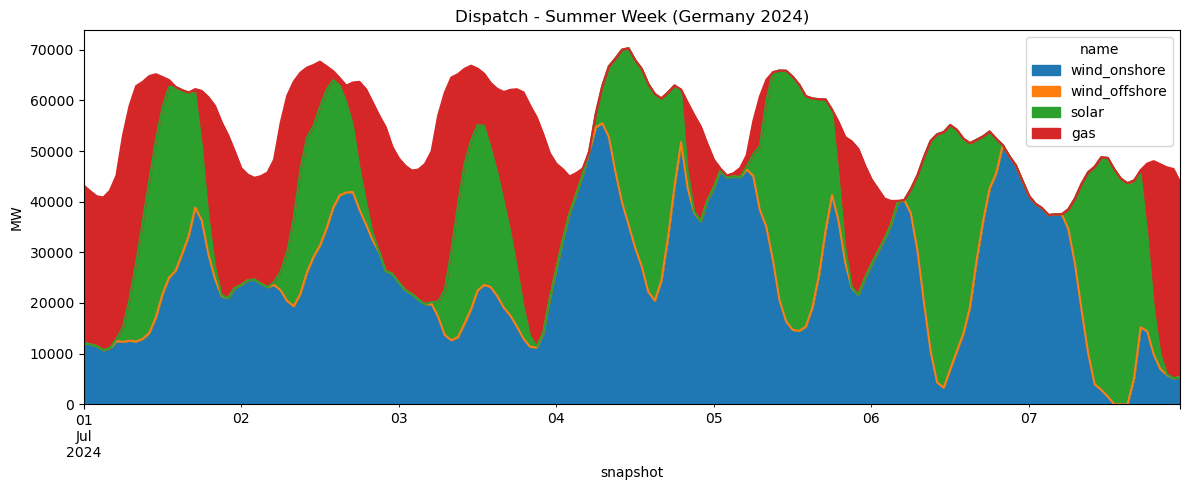


Saved figure in Plots folder.


In [12]:
summer = n.generators_t.p.loc["2024-07-01":"2024-07-07"]
summer.plot.area(figsize=(12, 5))
plt.title("Dispatch - Summer Week (Germany 2024)")
plt.ylabel("MW")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "summer_dispatch.png", dpi=200)
plt.show()
plt.close()

print("\nSaved figure in Plots folder.")

#### Winter Dispatch

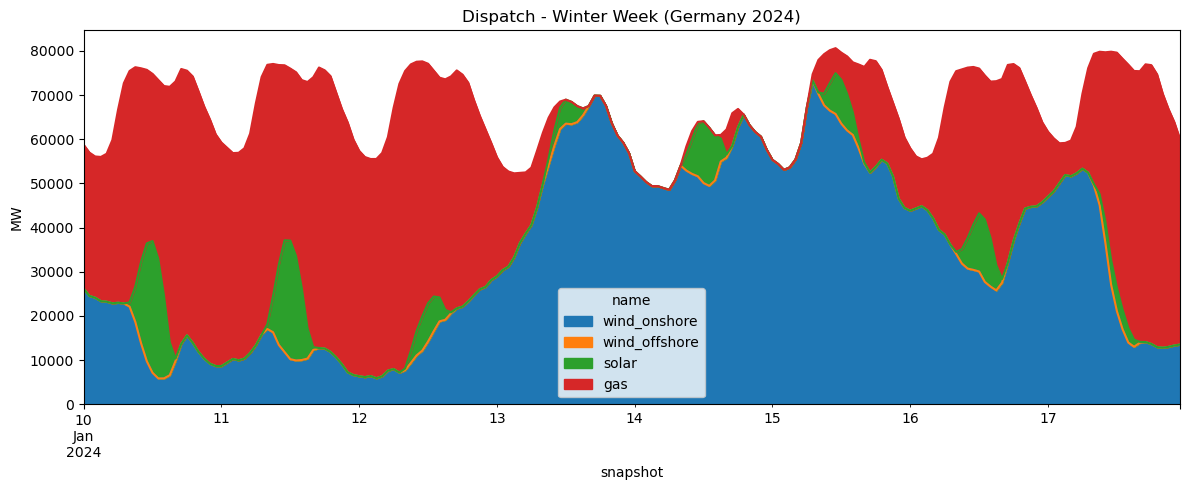


Saved figure in Plots folder.


In [13]:
winter = n.generators_t.p.loc["2024-01-10":"2024-01-17"]
winter.plot.area(figsize=(12, 5))
plt.title("Dispatch - Winter Week (Germany 2024)")
plt.ylabel("MW")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "winter_dispatch.png", dpi=200)
plt.show()
plt.close()

print("\nSaved figure in Plots folder.")

#### Annual Mix

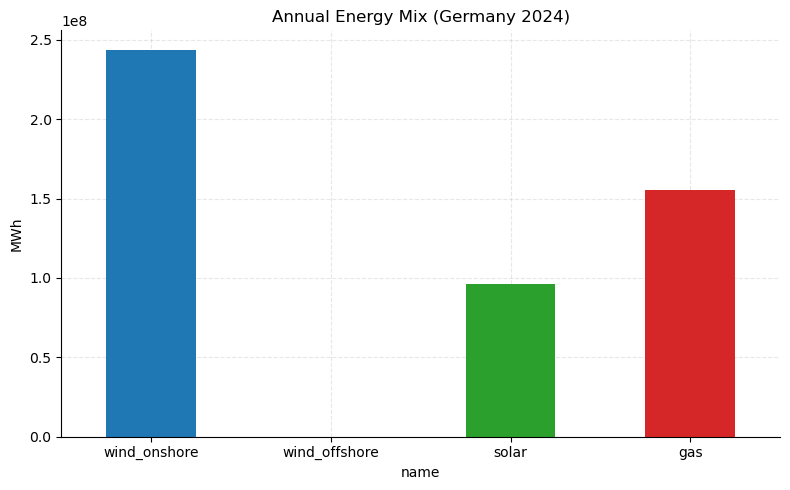

In [18]:
color_map = {
    "wind_onshore": "tab:blue",
    "wind_offshore": "tab:orange",
    "solar": "tab:green",
    "gas": "tab:red",
}

annual_mix = n.generators_t.p.sum()

ax = annual_mix.plot(
    kind="bar",
    figsize=(8, 5),
    color=[color_map.get(name, "gray") for name in annual_mix.index],
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_axisbelow(True)
ax.grid(True, linestyle="--",alpha=0.3)

plt.title("Annual Energy Mix (Germany 2024)")
plt.ylabel("MWh")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "annual_mix.png", dpi=200)
plt.show()
plt.close()


#### Duration Curves

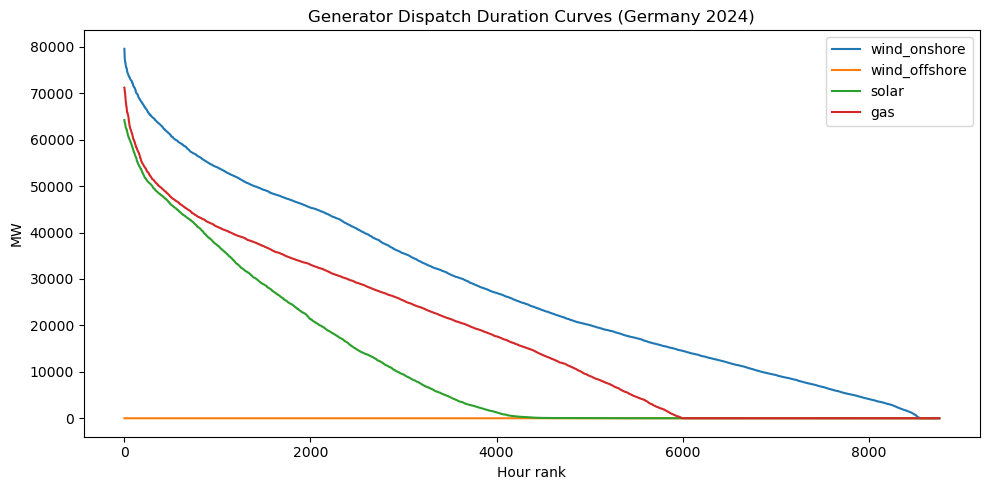


Saved figure in Plots folder.


In [15]:
plt.figure(figsize=(10, 5))
for gen_name in n.generators.index:
    sorted_dispatch = n.generators_t.p[gen_name].sort_values(ascending=False).reset_index(drop=True)
    plt.plot(sorted_dispatch, label=gen_name)

plt.title("Generator Dispatch Duration Curves (Germany 2024)")
plt.xlabel("Hour rank")
plt.ylabel("MW")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "duration_curves.png", dpi=200)
plt.show()
plt.close()

print("\nSaved figure in Plots folder.")

# Section B
Investigate how sensitive your results are to the interannual variability of solar and wind generation. Plot the average capacity and variability obtained for every generator using different weather years.


**Load different generation profiles**

For that we create a function that can extract the generation data from each individual file and we run it through a for loop for every single generation file and we put this data into a dictionary {}

In [66]:
def read_generation_file(filepath):
    # Read csv skipping the 2nd row with units
    gen_raw = pd.read_csv(filepath, skiprows=[1])
    gen_raw.columns = [str(c).strip() for c in gen_raw.columns]

    # Identify columns
    GENERATION_TIME_COL = gen_raw.columns[0]
    WIND_OFFSHORE_COL = "Wind offshore"
    WIND_ONSHORE_COL = "Wind onshore"
    SOLAR_COL = "Solar"

    # Parse time
    gen_raw[GENERATION_TIME_COL] = parse_time(gen_raw[GENERATION_TIME_COL])
    gen_raw = gen_raw.dropna(subset=[GENERATION_TIME_COL]).copy()
    gen_raw = gen_raw.set_index(GENERATION_TIME_COL)

    # Convert timezone to UTC and remove tz info
    if getattr(gen_raw.index, "tz", None) is not None:
        gen_raw.index = gen_raw.index.tz_convert("Europe/Berlin").tz_localize(None)
        gen_raw.index.name = "Date"

    # Build clean dataframe
    gen = pd.DataFrame(index=gen_raw.index)
    gen["wind_offshore"] = parse_number(gen_raw[WIND_OFFSHORE_COL])
    gen["wind_onshore"] = parse_number(gen_raw[WIND_ONSHORE_COL])
    gen["solar"] = parse_number(gen_raw[SOLAR_COL])

    # Clean and resample
    gen = gen.dropna().copy()
    gen = gen.groupby(gen.index).mean()
    gen = gen.resample("1h").mean()
    gen = gen.interpolate(method="time")
    gen = gen[~((gen.index.month == 2) & (gen.index.day == 29))].copy()  # Remove leap day if present

    #print(gen.shape)

    return gen


production_by_year = {}

files = sorted(DATA_DIR.glob("energy-charts_Total_net_electricity_generation_in_Germany_in_*.csv"))

for file in files:
    if "_load" in file.name:
        # Skipping "load" file
        continue

    year = int(file.stem.split("_")[-1])
    df_year = read_generation_file(file)

    df_year = df_year[(df_year.index >= f"{year}-01-01") & (df_year.index < f"{year+1}-01-01")]

    production_by_year[year] = df_year

print("Loaded production years successfully\n", production_by_year.keys())

Loaded production years successfully
 dict_keys([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])


### Installed technology capacities across years (in MW)

      mean_cf_onshore  mean_cf_offshore  mean_cf_solar
year                                                  
2015         0.196066          0.275650       0.115267
2016         0.166605          0.325458       0.109521
2017         0.196302          0.360107       0.108831
2018         0.193496          0.336271       0.116490
2019         0.212783          0.363292       0.109473
2020         0.214036          0.388288       0.108608
2021         0.183852          0.348365       0.100742
2022         0.191274          0.343734       0.108561
2023         0.216868          0.317154       0.092161
2024         0.197945          0.316254       0.091635
2025         0.175846          0.305798       0.095623


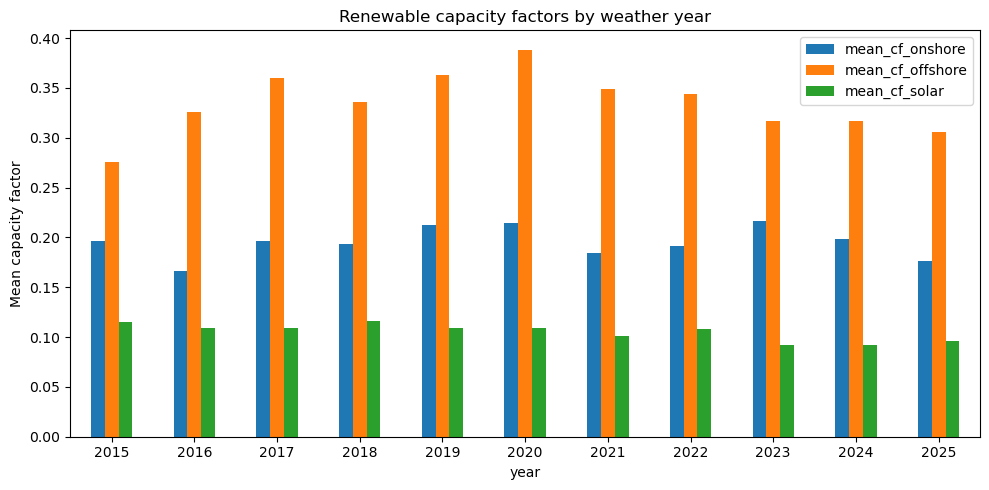

In [67]:
solar_cap = {
2015:36970, 2016:38330, 
2017:39860, 2018:42580, 
2019:46230, 2020:50920, 
2021:56070, 2022:62920, 
2023:76920, 2024:92410, 
2025:107400
}

onshore_cap = {
2015:41300, 2016:45280, 
2017:50170, 2018:52330, 
2019:53190, 2020:54410, 
2021:56050, 2022:58010, 
2023:61010, 2024:63590, 
2025:68220
}

offshore_cap = {
2015:3380, 2016:4240, 
2017:5520, 2018:6510, 
2019:7660, 2020:7870, 
2021:7870, 2022:8220, 
2023:8470, 2024:9220, 
2025:9730
}

cap_factor_each_year = []

for year, df_year in production_by_year.items():

    wind_onshore_cf  = (df_year["wind_onshore"] / onshore_cap[year]).clip(0,1)
    wind_offshore_cf = (df_year["wind_offshore"] / offshore_cap[year]).clip(0,1)
    solar_cf         = (df_year["solar"] / solar_cap[year]).clip(0,1)

    # This is just to calculate mean capacity factor for each technology and plot it
    cap_factor_each_year.append({
        "year": year,
        "mean_cf_onshore": wind_onshore_cf.mean(),
        "mean_cf_offshore": wind_offshore_cf.mean(),
        "mean_cf_solar": solar_cf.mean()
    })

cf_df = pd.DataFrame(cap_factor_each_year).set_index("year").sort_index()

print(cf_df)

cf_df.plot(kind="bar", figsize=(10,5))
plt.ylabel("Mean capacity factor")
plt.title("Renewable capacity factors by weather year")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "Cap_factor_per_year.png", dpi=200)
plt.show()
plt.close()

### Network build function per year
**Run model for every single production year**

In [68]:
def run_capacity_expansion_model(wind_onshore_cf, wind_offshore_cf, solar_cf):

    n = pypsa.Network()
    n.set_snapshots(demand_series.index)

    # ___ CARRIERS ___
    n.add("Carrier", "electricity")
    n.add("Carrier", "wind_onshore")
    n.add("Carrier", "wind_offshore")
    n.add("Carrier", "solar")
    n.add("Carrier", "gas")

    # ___ BUSES ___
    n.add("Bus", "Germany", carrier="electricity")

    # ___ LOADS ___
    n.add("Load", "demand", bus="Germany", p_set=demand_series)

    # ___ GENERATORS ___
    n.add(
        "Generator",
        "wind_onshore",
        bus="Germany",
        carrier="wind_onshore",
        p_nom_extendable=True,
        capital_cost=capital_cost_onshorewind,
        marginal_cost=marginal_cost_onshorewind,
        p_max_pu=wind_onshore_cf
    )

    n.add(
        "Generator",
        "wind_offshore",
        bus="Germany",
        carrier="wind_offshore",
        p_nom_extendable=True,
        capital_cost=capital_cost_offshorewind,
        marginal_cost=marginal_cost_offshorewind,
        p_max_pu=wind_offshore_cf
    )

    n.add(
        "Generator",
        "solar",
        bus="Germany",
        carrier="solar",
        p_nom_extendable=True,
        capital_cost=capital_cost_solar,
        marginal_cost=marginal_cost_solar,
        p_max_pu=solar_cf
    )

    n.add(
        "Generator",
        "gas",
        bus="Germany",
        carrier="gas",
        p_nom_extendable=True,
        capital_cost=capital_cost_gas,
        marginal_cost=marginal_cost_gas,
        p_max_pu=1.0
    )

    n.buses.index = n.buses.index.astype(object)
    n.loads.index = n.loads.index.astype(object)
    n.generators.index = n.generators.index.astype(object)
    n.loads["bus"] = n.loads["bus"].astype(object)
    n.generators["bus"] = n.generators["bus"].astype(object)

    # Solve model
    n.optimize(solver_name="highs")

    # Return optimal capacities
    return n.generators.p_nom_opt

In [69]:
print(demand_series.shape)

(8760,)


#### Optimize per year

In [70]:
part_b_results = []

for year, df_year in production_by_year.items():

    print(f"\nRunning model for weather year {year}")

    # We recompute the cf for every single hour of the year
    wind_onshore_cf  = (df_year["wind_onshore"] / onshore_cap[year]).clip(0,1)
    wind_offshore_cf = (df_year["wind_offshore"] / offshore_cap[year]).clip(0,1)
    solar_cf         = (df_year["solar"] / solar_cap[year]).clip(0,1)

    # IMPORTANT: align timestamps with network snapshots
    wind_onshore_cf.index  = demand_series.index
    wind_offshore_cf.index = demand_series.index
    solar_cf.index         = demand_series.index

    capacities = run_capacity_expansion_model(
        wind_onshore_cf,
        wind_offshore_cf,
        solar_cf
    )

    capacities = capacities.to_dict()
    capacities["year"] = year

    part_b_results.append(capacities)


Running model for weather year 2015


/var/folders/cy/3l6c31wj7j59912n8vx4tqx00000gn/T/ipykernel_84128/2717317480.py:71: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 547.20it/s]
INFO:linopy.io: Writing time: 0.05s


Running HiGHS 1.13.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-uu40jfef has 78844 rows; 35044 cols; 137973 nonzeros
Coefficient ranges:
  Matrix  [1e-06, 1e+00]
  Cost    [1e+02, 2e+05]
  Bound   [0e+00, 0e+00]
  RHS     [3e+04, 8e+04]
Presolving model
41609 rows, 32853 cols, 98547 nonzeros  0s
Dependent equations search running on 8760 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
41609 rows, 32853 cols, 98547 nonzeros  0s
Presolve reductions: rows 41609(-37235); columns 32853(-2191); nonzeros 98547(-39426) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(2.94296e+08) 0.1s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78844 duals
Objective: 3.65e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


      31940     3.6467858982e+10 Pr: 0(0); Du: 0(8.24233e-10) 1.5s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-uu40jfef
Model status        : Optimal
Simplex   iterations: 31940
Objective value     :  3.6467858982e+10
P-D objective error :  2.0920873185e-15
HiGHS run time      :          1.58

Running model for weather year 2016


...

      32062     3.6140734671e+10 Pr: 0(0); Du: 0(2.35415e-08) 2.4s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-9xsrncw9
Model status        : Optimal
Simplex   iterations: 32062
Objective value     :  3.6140734671e+10
P-D objective error :  1.0555118207e-15
HiGHS run time      :          2.45

Running model for weather year 2025


/var/folders/cy/3l6c31wj7j59912n8vx4tqx00000gn/T/ipykernel_84128/2717317480.py:71: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 558.35it/s]
INFO:linopy.io: Writing time: 0.04s


Running HiGHS 1.13.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-tjv93or3 has 78844 rows; 35044 cols; 137972 nonzeros
Coefficient ranges:
  Matrix  [3e-06, 1e+00]
  Cost    [1e+02, 2e+05]
  Bound   [0e+00, 0e+00]
  RHS     [3e+04, 8e+04]
Presolving model
41608 rows, 32852 cols, 98544 nonzeros  0s
Dependent equations search running on 8760 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
41608 rows, 32852 cols, 98544 nonzeros  0s
Presolve reductions: rows 41608(-37236); columns 32852(-2192); nonzeros 98544(-39428) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(1.22925e+08) 0.1s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78844 duals
Objective: 3.78e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


      32747     3.7766517758e+10 Pr: 0(0); Du: 0(5.82871e-09) 1.1s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-tjv93or3
Model status        : Optimal
Simplex   iterations: 32747
Objective value     :  3.7766517758e+10
P-D objective error :  3.0302216026e-16
HiGHS run time      :          1.14


### Plots & Results

In [71]:
part_b_df = pd.DataFrame(part_b_results).set_index("year").sort_index()
mean_capacity = part_b_df.mean()
std_variability = part_b_df.std()
coefficient_of_variation = std_variability / mean_capacity

print("\nOptimal capacities for each weather year:")
print(part_b_df)

summary_b = pd.DataFrame({
    "Mean capacity (MW)": mean_capacity,
    "Std Deviation (MW)": std_variability,
    "Coeff of variation (%)": coefficient_of_variation*100
})

print(summary_b.round(2))


Optimal capacities for each weather year:
       wind_onshore  wind_offshore          solar           gas
year                                                           
2015  160702.189196           -0.0  116306.699958  73802.650558
2016  170768.030006           -0.0  120573.866560  70949.462285
2017  158898.505173           -0.0  113912.041136  74949.106448
2018  170866.533213           -0.0  114236.275445  74374.823144
2019  171793.776554           -0.0  110550.437273  73025.630426
2020  167686.757089           -0.0  111328.164263  71235.007396
2021  170996.044797           -0.0  121898.964953  71539.954429
2022  158231.103956           -0.0  122290.121530  74386.434347
2023  162765.707184           -0.0  120807.030740  70387.981563
2024  172012.565506           -0.0  122564.021221  71202.428511
2025  176116.717597           -0.0  126995.781475  73325.975919
               Mean capacity (MW)  Std Deviation (MW)  Coeff of variation (%)
wind_onshore            167348.90             6

#### Mean and Std deviation capacities

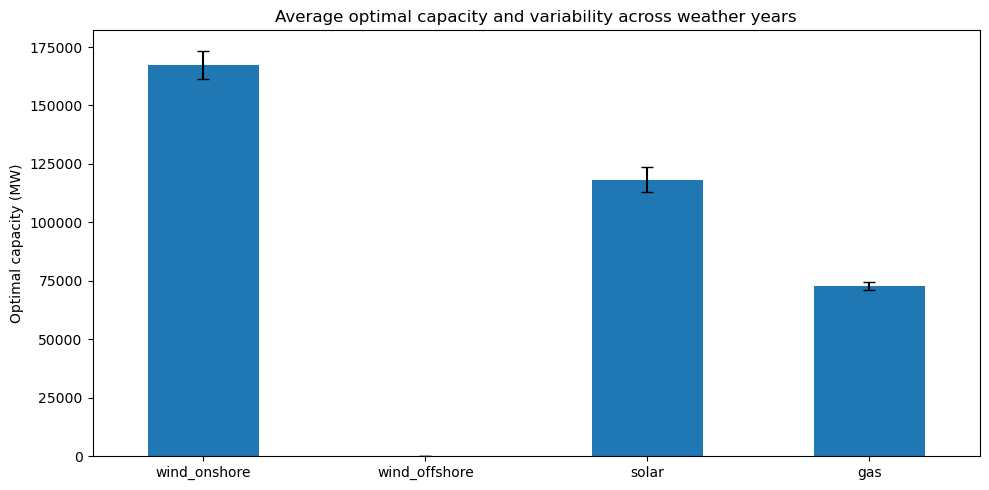


Saved figure in Plots folder.


In [72]:
mean_capacity.plot(kind="bar", yerr=std_variability, capsize=4, figsize=(10,5))
plt.ylabel("Optimal capacity (MW)")
plt.title("Average optimal capacity and variability across weather years")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "capacity_variability.png", dpi=200)
plt.show()
plt.close()
print("\nSaved figure in Plots folder.")   

#### Optimal capacities across years

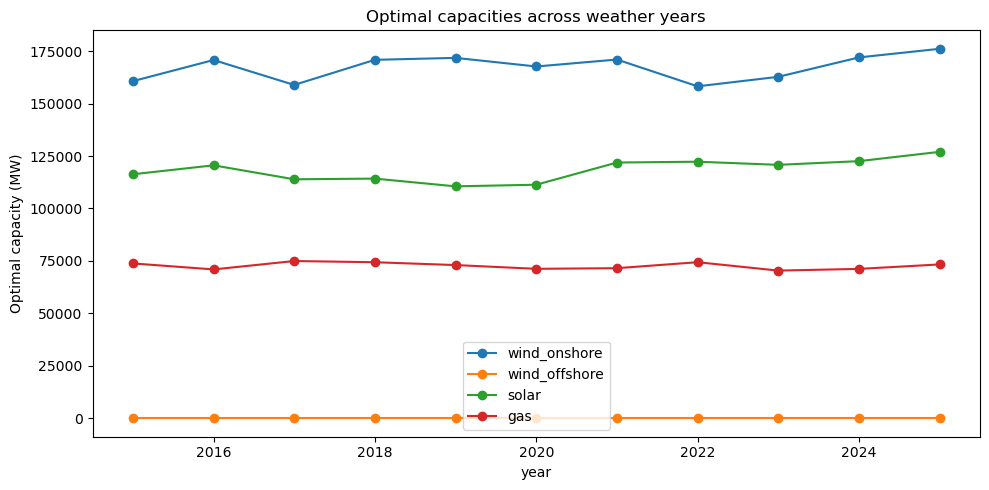


Saved figure in Plots folder.


In [73]:
part_b_df.plot(marker="o", figsize=(10,5))
plt.ylabel("Optimal capacity (MW)")
plt.title("Optimal capacities across weather years")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "Opt_cap_across_years.png", dpi=200)
plt.show()
plt.close()
print("\nSaved figure in Plots folder.")   

# Section C
Add some storage technology/ies and investigate how they behave and what their impact is on the optimal system configuration. Discuss what strategies your system is using to balance the renewable generation at different time scales (intraday, seasonal, etc.)


## Storage Technicalities

In [74]:
discount_rate = 0.07

# Battery Energy Storage System (BESS)
lifetime_BESS = 15  # years
BESS_max_hours = 6
BESS_eff_disch = 0.9
BESS_eff_ch = 0.9
BESS_roundtrip_eff = BESS_eff_disch * BESS_eff_ch

BESS_CAPEX_MWh = 144600 # EUR/MWh
BESS_CAPEX_MW_FOR_INVERTER = 310000 #EUR/MW
BESS_total_cost_per_MW = BESS_CAPEX_MWh * BESS_max_hours + BESS_CAPEX_MW_FOR_INVERTER

fixed_OM_BESS_for_inverter = 0.03 #FOM
capital_cost_BESS = annuity(lifetime_BESS, discount_rate) * BESS_total_cost_per_MW * (1 + fixed_OM_BESS_for_inverter)   # EUR/MW-year
marginal_cost_BESS = 0

## Model with storage

In [75]:
def network_model_with_storage(wind_onshore_cf, wind_offshore_cf, solar_cf):
    n = pypsa.Network()
    n.set_snapshots(demand_series.index)

    # ___ CARRIERS ___
    n.add("Carrier", "electricity")
    n.add("Carrier", "wind_onshore")
    n.add("Carrier", "wind_offshore")
    n.add("Carrier", "solar")
    n.add("Carrier", "gas")
    n.add("Carrier", "battery")
    

    # ___ BUSES ___
    n.add("Bus", "Germany", carrier="electricity")

    # ___ LOADS ___
    n.add("Load", "demand", bus="Germany", p_set=demand_series)

    # ___ GENERATORS ___
    n.add(
        "Generator",
        "wind_onshore",
        bus="Germany",
        carrier="wind_onshore",
        p_nom_extendable=True,
        capital_cost=capital_cost_onshorewind,
        marginal_cost=marginal_cost_onshorewind,
        p_max_pu=wind_onshore_cf
    )

    n.add(
        "Generator",
        "wind_offshore",
        bus="Germany",
        carrier="wind_offshore",
        p_nom_extendable=True,
        capital_cost=capital_cost_offshorewind,
        marginal_cost=marginal_cost_offshorewind,
        p_max_pu=wind_offshore_cf
    )

    n.add(
        "Generator",
        "solar",
        bus="Germany",
        carrier="solar",
        p_nom_extendable=True,
        capital_cost=capital_cost_solar,
        marginal_cost=marginal_cost_solar,
        p_max_pu=solar_cf
    )

    n.add(
        "Generator",
        "gas",
        bus="Germany",
        carrier="gas",
        p_nom_extendable=True,
        capital_cost=capital_cost_gas,
        marginal_cost=marginal_cost_gas,
        p_max_pu=1.0
    )

    # ___ STORAGE ___ <-----------------------------------------!!!!
    n.add(
        "StorageUnit",
        "battery",
        bus="Germany",
        carrier="battery",
        p_nom_extendable=True,
        capital_cost=capital_cost_BESS,
        marginal_cost=marginal_cost_BESS,
        efficiency_store=BESS_eff_ch,
        efficiency_dispatch=BESS_eff_disch,
        max_hours=BESS_max_hours,
        cyclic_state_of_charge=True
    )


    n.buses.index = n.buses.index.astype(object)
    n.loads.index = n.loads.index.astype(object)
    n.generators.index = n.generators.index.astype(object)
    n.storage_units.index = n.storage_units.index.astype(object)
    n.loads["bus"] = n.loads["bus"].astype(object)
    n.generators["bus"] = n.generators["bus"].astype(object)
    n.storage_units.index = n.storage_units.index.astype(object)

    # Solve model
    n.optimize(solver_name="highs")

    generator_caps = n.generators.p_nom_opt.to_dict()
    storage_caps = n.storage_units.p_nom_opt.to_dict()

    results = {**generator_caps, **storage_caps}

    return results, n

**Model Run**

In [76]:
import pandas as pd
pd.options.mode.string_storage = "python"

part_c_results = []

year = 2024
df_year = production_by_year[year]
#for year, df_year in production_by_year.items():

print(f"\nRunning model WITH STORAGE for weather year {year}")

# We recompute the cf for every single hour of the year
wind_onshore_cf  = (df_year["wind_onshore"] / onshore_cap[year]).clip(0,1)
wind_offshore_cf = (df_year["wind_offshore"] / offshore_cap[year]).clip(0,1)
solar_cf         = (df_year["solar"] / solar_cap[year]).clip(0,1)

# IMPORTANT: align timestamps with network snapshots
wind_onshore_cf.index  = demand_series.index
wind_offshore_cf.index = demand_series.index
solar_cf.index         = demand_series.index

capacities, n_storage = network_model_with_storage(
    wind_onshore_cf,
    wind_offshore_cf,
    solar_cf
)

part_c_results.append({"year": year,**capacities})
part_c_df = pd.DataFrame(part_c_results).set_index("year")
print(part_c_df)


Running model WITH STORAGE for weather year 2024


/var/folders/cy/3l6c31wj7j59912n8vx4tqx00000gn/T/ipykernel_84128/4213661077.py:90: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 745.50it/s]
INFO:linopy.io: Writing time: 0.06s


Running HiGHS 1.13.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-tiqm2nfy has 140165 rows; 61325 cols; 269369 nonzeros
Coefficient ranges:
  Matrix  [3e-06, 6e+00]
  Cost    [1e+02, 2e+05]
  Bound   [0e+00, 0e+00]
  RHS     [3e+04, 8e+04]
Presolving model
76644 rows, 59129 cols, 203652 nonzeros  0s
Dependent equations search running on 17520 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
76644 rows, 59129 cols, 203652 nonzeros  0s
Presolve reductions: rows 76644(-63521); columns 59129(-2196); nonzeros 203652(-65717) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(1.38788e+08) 0.1s
      63166     3.5964156953e+10 Pr: 2854(1.34349e+07) 5.2s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61325 primals, 140165 duals
Objective: 3.61e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


      67634     3.6130684988e+10 Pr: 0(0); Du: 0(1.51587e-08) 6.0s
      67634     3.6130684988e+10 Pr: 0(0); Du: 0(1.51587e-08) 6.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-tiqm2nfy
Model status        : Optimal
Simplex   iterations: 67634
Objective value     :  3.6130684988e+10
P-D objective error :  3.6953189329e-15
HiGHS run time      :          6.08
       wind_onshore  wind_offshore          solar           gas      battery
year                                                                        
2024  171735.926583           -0.0  126393.370988  69011.248902  2191.400579


## Results and plots

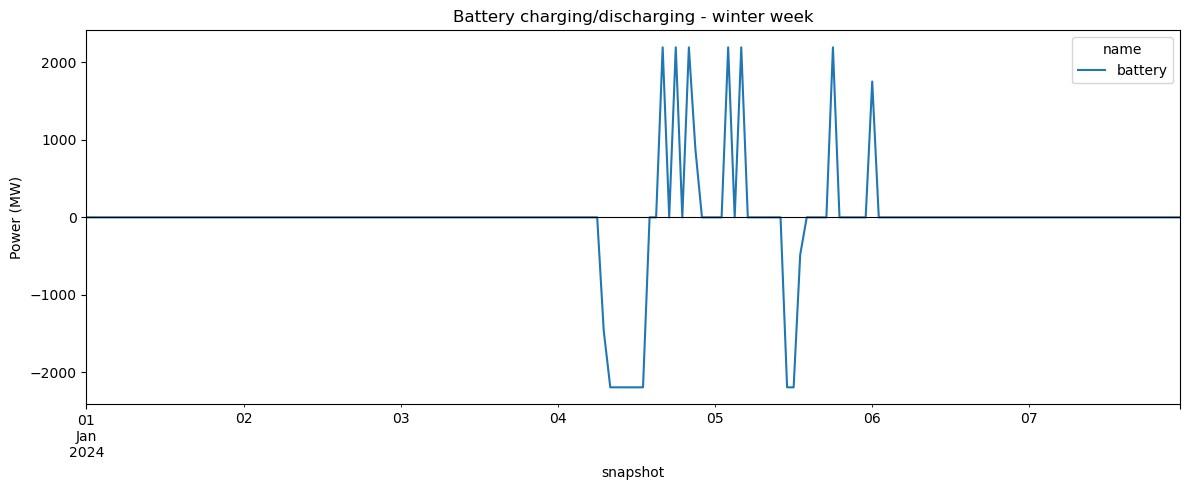

In [77]:

n_storage.storage_units_t.p[["battery"]].loc["2024-01-01":"2024-01-07"].plot(figsize=(12,5))
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Power (MW)")
plt.title("Battery charging/discharging - winter week")
plt.tight_layout()
plt.show()


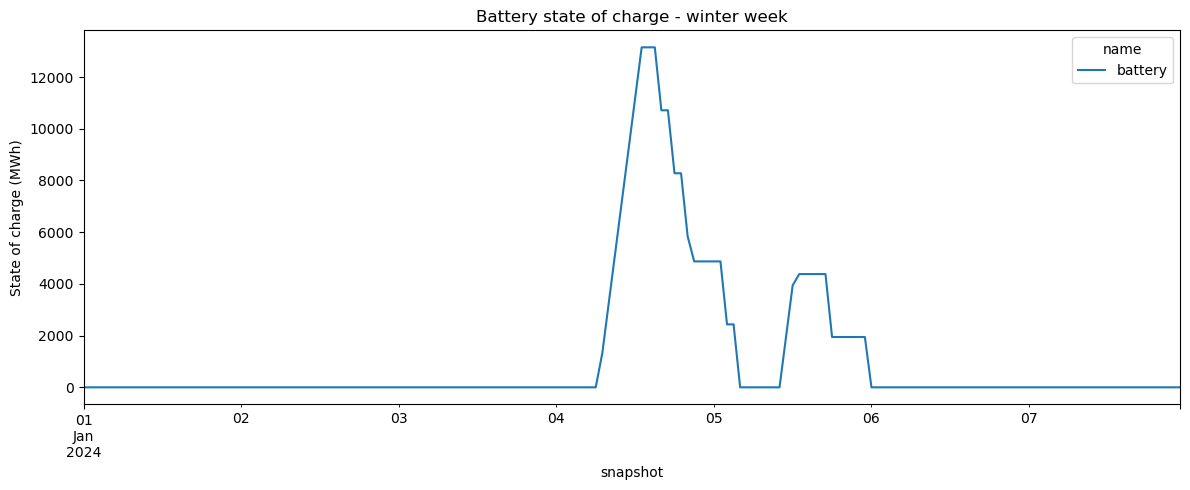

In [78]:

n_storage.storage_units_t.state_of_charge[["battery"]].loc["2024-01-01":"2024-01-07"].plot(figsize=(12,5))
plt.ylabel("State of charge (MWh)")
plt.title("Battery state of charge - winter week")
plt.tight_layout()
plt.show()

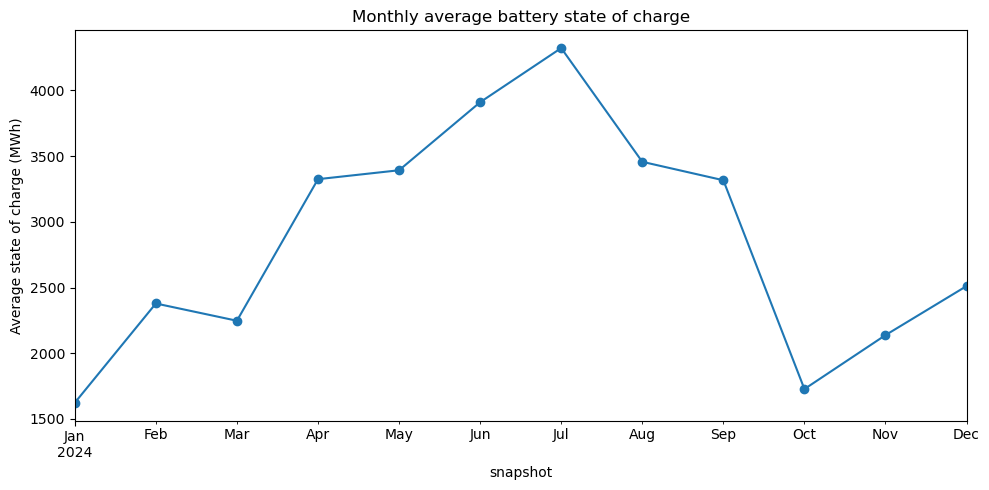

In [79]:
soc_monthly = n_storage.storage_units_t.state_of_charge["battery"].resample("ME").mean()

soc_monthly.plot(marker="o", figsize=(10,5))
plt.ylabel("Average state of charge (MWh)")
plt.title("Monthly average battery state of charge")
plt.tight_layout()
plt.show()

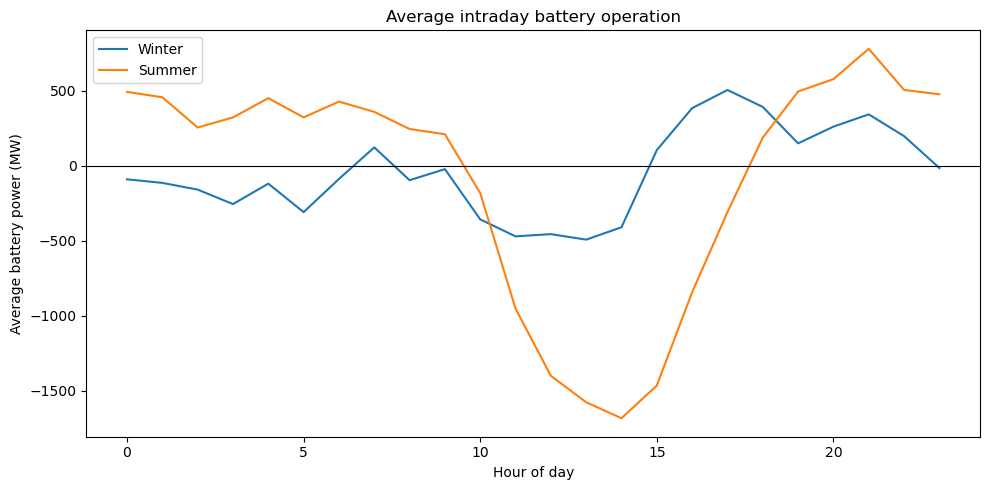

In [80]:
battery_p = n_storage.storage_units_t.p["battery"]

winter = battery_p.loc["2024-01-01":"2024-02-28"]
summer = battery_p.loc["2024-06-01":"2024-08-31"]

winter_hourly = winter.groupby(winter.index.hour).mean()
summer_hourly = summer.groupby(summer.index.hour).mean()

plt.figure(figsize=(10,5))
plt.plot(winter_hourly.index, winter_hourly.values, label="Winter")
plt.plot(summer_hourly.index, summer_hourly.values, label="Summer")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Hour of day")
plt.ylabel("Average battery power (MW)")
plt.title("Average intraday battery operation")
plt.legend()
plt.tight_layout()
plt.show()

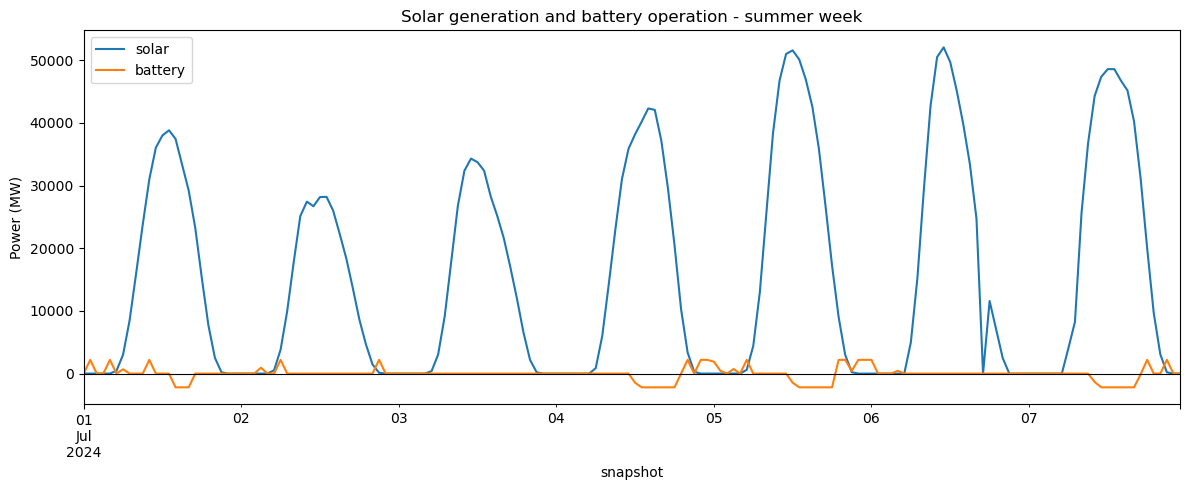

In [81]:
plot_df = pd.DataFrame({
    "solar": n_storage.generators_t.p["solar"],
    "battery": n_storage.storage_units_t.p["battery"]
}).loc["2024-07-01":"2024-07-07"]

plot_df.plot(figsize=(12,5))
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Power (MW)")
plt.title("Solar generation and battery operation - summer week")
plt.tight_layout()
plt.show()

# Section D
Connect your country to at least three neighbouring countries using HVAC lines, making sure that the network includes at least one closed cycle. Look for information on the existing capacities of those interconnectors and set the capacities fixed. Assume a voltage level of 400 kV and a unitary reactance x=0.1. You can assume that the generation capacities in the neighbouring countries are fixed or co-optimise the whole system. Optimise the whole system, assuming linearised AC power flow (DC approximation) and discuss the results.


n.add("Carrier", "electricity")

n.add("Bus", "DE", carrier="electricity")
n.add("Bus", "FR", carrier="electricity")

n.add(
    "Line",
    "DE-FR",
    bus0="DE",
    bus1="FR",
    s_nom=10000,   # MW (or MVA)
    v_nom=400,     # kV
    x=0.1          # reactance (use your assignment assumption consistently)
)


## Data
### Functions to extract data from API
Data (for 2024):
- Power production of each tech
- Installed power of each tech
- Installed capacities
- Cross border power flow

In [82]:
# DATA IMPORTS
import re
import math
import requests
import numpy as np
import pandas as pd
import pypsa

API_BASE = "https://api.energy-charts.info"
START_2024 = "2024-01-01"
END_2024 = "2024-12-31"

COUNTRY_CODES = {
    "Germany": "de",
    "Belgium": "be",
    "France": "fr",
    "Netherlands": "nl",
}

NETWORK_EDGES = [
    ("Germany", "Belgium"),
    ("Germany", "France"),
    ("Germany", "Netherlands"),
    ("Belgium", "France"),
    ("Belgium", "Netherlands"),
]


def slugify(text: str) -> str:
    """
    Slugify does the following transformations to a string:
    - Convert to lowercase
    - Replace spaces and special characters with underscores
    - Remove leading/trailing underscores
    - Replace multiple underscores with a single underscore
    returns a clean, standardized string that can be used as an identifier or key.
    """
    text = text.lower().strip()
    text = text.replace("-", " ").replace("/", " ")
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text


def ec_get(endpoint: str, **params):
    """
    energy charts API GET request helper function. 
    It constructs the URL, sends a GET request with the provided parameters, 
    checks for successful response, and returns the JSON data as a Python dictionary.
    """
    url = f"{API_BASE}/{endpoint}"
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    return response.json()


def get_public_power_df(country_code: str, start=START_2024, end=END_2024) -> pd.DataFrame:
    """
    Gets the public power production data for a given country and time range from the energy charts API,
    and returns it as a pandas DataFrame with timestamps as the index and production types as columns
    """
    data_json = ec_get("public_power", country=country_code, start=start, end=end)

    timestamps = pd.to_datetime(data_json["unix_seconds"], unit="s", utc=True)
    data = {}

    for item in data_json["production_types"]:
        data[slugify(item["name"])] = item["data"]

    df = pd.DataFrame(data, index=timestamps).sort_index()
    df = df.resample("1h").mean()
    df.index = df.index.tz_convert(None)
    return df


def get_installed_power_2024(country_code: str) -> pd.Series:
    """
    Gets the installed power data for a given country in the year 2024 from the energy charts API,
    and returns it as a pandas Series with production types as the index and capacities as values.
    """
    data_json = ec_get("installed_power", country=country_code, time_step="yearly")

    years = [str(t) for t in data_json["time"]]
    year_position = years.index("2024")

    values = {}
    for item in data_json["production_types"]:
        values[slugify(item["name"])] = item["data"][year_position]

    series = pd.Series(values, dtype=float)

    # installed power is given in GW -> convert to MW
    series = series * 1000.0
    return series


def get_cbpf_df(country_code: str, start=START_2024, end=END_2024) -> pd.DataFrame:
    """
    Fetch hourly cross-border physical flow data (GW) for a country and its neighbors from the Energy Charts API.
    """
    data_json = ec_get("cbpf", country=country_code, start=start, end=end)

    timestamps = pd.to_datetime(data_json["unix_seconds"], unit="s", utc=True)
    data = {}

    for item in data_json["countries"]:
        data[slugify(item["name"])] = item["data"]

    df = pd.DataFrame(data, index=timestamps).sort_index()
    df = df.resample("1h").mean()
    df.index = df.index.tz_convert(None)
    return df


def find_best_matching_key(keys, patterns):
    """
    First try exact slug matches: sllugged keys are essentially the original keys transformed into a standardized format using the slugify function.
    If this doesnt work:
    Then try 'pattern in key' matches: which is a more flexible approach that checks if the slugified pattern is a substring of any of the slugified keys.
    A pattern is basically a keyword that we expect to find in the column names of the dataframes, such as "solar", "wind_onshore", "load", etc.
    """
    slugged_keys = {slugify(k): k for k in keys}

    for pattern in patterns:
        pattern_slug = slugify(pattern)
        if pattern_slug in slugged_keys:
            return slugged_keys[pattern_slug]

    for pattern in patterns:
        pattern_slug = slugify(pattern)
        for key_slug, original_key in slugged_keys.items():
            if pattern_slug in key_slug:
                return original_key

    return None


def extract_installed_capacities(installed_power_series: pd.Series) -> dict:
    """
    Extracts the installed capacities for the technologies from the installed power series.
    The function uses a mapping of technology names to patterns that are expected to be found 
    in the index of the installed power series. 
    It then uses the find_best_matching_key function to find the best matching key for each technology and extracts the corresponding capacity value.
    """
    
    keys = list(installed_power_series.index)

    mapping = {
        "wind_onshore": ["wind_onshore", "onshore"],
        "wind_offshore": ["wind_offshore", "offshore"],
        "solar": ["solar", "pv", "photovoltaic", "photovoltaics"],
        "gas": ["fossil_gas", "gas"],
    }

    capacities = {}
    for tech, patterns in mapping.items():
        key = find_best_matching_key(keys, patterns)
        capacities[tech] = float(installed_power_series[key]) if key is not None else 0.0

    return capacities


def extract_generation_bundle(public_power_df: pd.DataFrame) -> dict:
    """
    Extracts the generation from the total power dataframe
    It splits it into the technologies for the network model and a residual gen
    which captures the diff between observed gen and modelled gen, this can be used
    as a proxy for unmodelled generation and also for data errors.
    """

    columns = list(public_power_df.columns)

    load_key = find_best_matching_key(columns, ["load"])
    if load_key is None:
        raise ValueError(f"Load column not found. Available columns: {columns}")

    solar_key = find_best_matching_key(columns, ["solar", "pv", "photovoltaic", "photovoltaics"])
    wind_onshore_key = find_best_matching_key(columns, ["wind_onshore", "onshore"])
    wind_offshore_key = find_best_matching_key(columns, ["wind_offshore", "offshore"])
    gas_key = find_best_matching_key(columns, ["fossil_gas", "gas"])

    load = pd.to_numeric(public_power_df[load_key], errors="coerce").fillna(0.0)

    solar = pd.to_numeric(public_power_df[solar_key], errors="coerce").fillna(0.0) if solar_key else pd.Series(0.0, index=public_power_df.index)
    wind_onshore = pd.to_numeric(public_power_df[wind_onshore_key], errors="coerce").fillna(0.0) if wind_onshore_key else pd.Series(0.0, index=public_power_df.index)
    wind_offshore = pd.to_numeric(public_power_df[wind_offshore_key], errors="coerce").fillna(0.0) if wind_offshore_key else pd.Series(0.0, index=public_power_df.index)
    gas = pd.to_numeric(public_power_df[gas_key], errors="coerce").fillna(0.0) if gas_key else pd.Series(0.0, index=public_power_df.index)

    # total observed generation = all columns except load
    generation_columns = [col for col in public_power_df.columns if col != load_key]
    total_generation = public_power_df[generation_columns].apply(pd.to_numeric, errors="coerce").fillna(0.0).sum(axis=1)

    # residual generation = all observed generation not explicitly modelled
    residual_generation = total_generation - solar - wind_onshore - wind_offshore - gas
    residual_generation = residual_generation.clip(lower=0.0)

    return {
        "load": load.clip(lower=0.0),
        "solar": solar.clip(lower=0.0),
        "wind_onshore": wind_onshore.clip(lower=0.0),
        "wind_offshore": wind_offshore.clip(lower=0.0),
        "gas": gas.clip(lower=0.0),
        "residual_generation": residual_generation,
    }


def get_observed_line_capacity_mw(country_a: str, country_b: str) -> float:
    """
    Use the maximum absolute observed physical flow in 2024 as a data-based proxy for s_nom.
    s_nom is the maximum capacity of the transmission line between two countries in the network model using fct: 
    The function first tries to find a cross-border flow series in the capacity factor dataframe of country_a
    that matches country_b, if it finds it, it calculates the maximum absolute flow and returns it as the line capacity in MW.
    If it doesn't find a matching series in country_a, it tries the same in country_bs dataframe.
    If it doesn't find any matching series in either country, it raises an error.
    """
    code_a = COUNTRY_CODES[country_a]
    code_b = COUNTRY_CODES[country_b]

    df_a = get_cbpf_df(code_a)
    col_a = find_best_matching_key(df_a.columns, [country_b])

    if col_a is not None:
        max_gw = float(df_a[col_a].abs().max())
        return math.ceil(max_gw * 1000.0)

    df_b = get_cbpf_df(code_b)
    col_b = find_best_matching_key(df_b.columns, [country_a])

    if col_b is not None:
        max_gw = float(df_b[col_b].abs().max())
        return math.ceil(max_gw * 1000.0)

    raise ValueError(f"No cross-border flow series found for {country_a} and {country_b}")

### Extract and prepare data

In [83]:
country_data = {} 
#Empty dict to store all the data for each country, structured as country_data[country_name][variable_name] = series

for country_name, country_code in COUNTRY_CODES.items():
    public_power = get_public_power_df(country_code)
    installed_power = get_installed_power_2024(country_code)

    observed = extract_generation_bundle(public_power)
    capacities_mw = extract_installed_capacities(installed_power)

    cf_onshore = (
        observed["wind_onshore"] / capacities_mw["wind_onshore"]
        if capacities_mw["wind_onshore"] > 0
        else pd.Series(0.0, index=public_power.index)
    )

    cf_offshore = (
        observed["wind_offshore"] / capacities_mw["wind_offshore"]
        if capacities_mw["wind_offshore"] > 0
        else pd.Series(0.0, index=public_power.index)
    )

    cf_solar = (
        observed["solar"] / capacities_mw["solar"]
        if capacities_mw["solar"] > 0
        else pd.Series(0.0, index=public_power.index)
    )

    country_data[country_name] = {
        "load": observed["load"],
        "gas_dispatch": observed["gas"],
        "residual_generation": observed["residual_generation"],
        "cf_onshore": cf_onshore.clip(lower=0, upper=1),
        "cf_offshore": cf_offshore.clip(lower=0, upper=1),
        "cf_solar": cf_solar.clip(lower=0, upper=1),
        "capacities_mw": capacities_mw,
    }

# This snapshot helps align all the time series data to the same timestamp of Germany
snapshots = country_data["Germany"]["load"].index

for country_name in country_data:
    for variable_name in [
        "load",
        "gas_dispatch",
        "residual_generation",
        "cf_onshore",
        "cf_offshore",
        "cf_solar",
    ]:
        series = country_data[country_name][variable_name]
        series = series.reindex(snapshots)
        series = series.interpolate().ffill().bfill()
        country_data[country_name][variable_name] = series

line_capacities_mw = {}
for bus0, bus1 in NETWORK_EDGES:
    line_capacities_mw[(bus0, bus1)] = get_observed_line_capacity_mw(bus0, bus1)

print("Installed capacities in 2024 (MW):")
for country_name in country_data:
    print(f"\n{country_name}")
    print(pd.Series(country_data[country_name]["capacities_mw"]))

print("\nInterconnector capacities used in the model (MW):")
for edge, value in line_capacities_mw.items():
    print(f"{edge}: {value}")

Installed capacities in 2024 (MW):

Germany
wind_onshore      63589.0
wind_offshore      9215.0
solar            100686.0
gas               35601.0
dtype: float64

Belgium
wind_onshore      3180.0
wind_offshore     2260.0
solar            10700.0
gas               8350.0
dtype: float64

France
wind_onshore     22910.0
wind_offshore     1030.0
solar            22860.0
gas              12790.0
dtype: float64

Netherlands
wind_onshore      7180.0
wind_offshore     4740.0
solar            29280.0
gas              18410.0
dtype: float64

Interconnector capacities used in the model (MW):
('Germany', 'Belgium'): 1012
('Germany', 'France'): 4628
('Germany', 'Netherlands'): 5175
('Belgium', 'France'): 5129
('Belgium', 'Netherlands'): 3743


##### Residual costs - WAITING FOR BETTER DATA


In [84]:
# Residual marginal cost assumption (EUR/MWh)
# Lower for France because residual likely proxies more nuclear/hydro-like generation
# Higher for Netherlands because residual is more thermal-like
residual_marginal_cost = {
    "France": 10.0,
    "Belgium": 20.0,
    "Netherlands": 30.0,
}

## Build Network

In [85]:
def build_part_d_network(country_data, line_capacities_mw):
    network = pypsa.Network()
    network.set_snapshots(snapshots)

    if "AC" not in network.carriers.index:
        network.add("Carrier", "AC")

    # Adding Carriers
    for carrier in [
        "electricity",
        "wind_onshore",
        "wind_offshore",
        "solar",
        "gas",
        "battery",
        "residual"
    ]:
        if carrier not in network.carriers.index:
            network.add("Carrier", carrier)

    # Adding buses with 400 kV for all countries so that they can be connected with lines without needing transformers
    for country_name in country_data.keys():
        network.add("Bus", country_name, carrier="AC", v_nom=400.0)

    # Adding loads
    for country_name in country_data.keys():
        network.add(
            "Load",
            f"load_{country_name}",
            bus=country_name,
            p_set=country_data[country_name]["load"]
        )


    # Germany: extendable capacities

    germany_data = country_data["Germany"]

    network.add(
        "Generator",
        "wind_onshore_DE",
        bus="Germany",
        carrier="wind_onshore",
        p_nom_extendable=True,
        capital_cost=capital_cost_onshorewind,
        marginal_cost=marginal_cost_onshorewind,
        p_max_pu=germany_data["cf_onshore"]
    )

    network.add(
        "Generator",
        "wind_offshore_DE",
        bus="Germany",
        carrier="wind_offshore",
        p_nom_extendable=True,
        capital_cost=capital_cost_offshorewind,
        marginal_cost=marginal_cost_offshorewind,
        p_max_pu=germany_data["cf_offshore"]
    )

    network.add(
        "Generator",
        "solar_DE",
        bus="Germany",
        carrier="solar",
        p_nom_extendable=True,
        capital_cost=capital_cost_solar,
        marginal_cost=marginal_cost_solar,
        p_max_pu=germany_data["cf_solar"]
    )

    network.add(
        "Generator",
        "gas_DE",
        bus="Germany",
        carrier="gas",
        p_nom_extendable=True,
        capital_cost=capital_cost_gas,
        marginal_cost=marginal_cost_gas,
        p_max_pu=1.0
    )

    network.add(
        "StorageUnit",
        "battery_DE",
        bus="Germany",
        carrier="battery",
        p_nom_extendable=True,
        capital_cost=capital_cost_BESS,
        marginal_cost=marginal_cost_BESS,
        efficiency_store=BESS_eff_ch,
        efficiency_dispatch=BESS_eff_disch,
        max_hours=BESS_max_hours,
        cyclic_state_of_charge=True
    )

    # Neighbour countries
    # FIXED installed capacities from Energy-Charts
    # Residual generation modelled as dispatchable availability
    for country_name in ["Belgium", "France", "Netherlands"]:
        capacities_mw = country_data[country_name]["capacities_mw"]

        # wind onshore
        network.add(
            "Generator",
            f"wind_onshore_{country_name}",
            bus=country_name,
            carrier="wind_onshore",
            p_nom=max(capacities_mw["wind_onshore"], 0.0),
            p_nom_extendable=False,
            marginal_cost=marginal_cost_onshorewind,
            p_max_pu=country_data[country_name]["cf_onshore"]
        )

        # wind offshore
        network.add(
            "Generator",
            f"wind_offshore_{country_name}",
            bus=country_name,
            carrier="wind_offshore",
            p_nom=max(capacities_mw["wind_offshore"], 0.0),
            p_nom_extendable=False,
            marginal_cost=marginal_cost_offshorewind,
            p_max_pu=country_data[country_name]["cf_offshore"]
        )

        # solar
        network.add(
            "Generator",
            f"solar_{country_name}",
            bus=country_name,
            carrier="solar",
            p_nom=max(capacities_mw["solar"], 0.0),
            p_nom_extendable=False,
            marginal_cost=marginal_cost_solar,
            p_max_pu=country_data[country_name]["cf_solar"]
        )

        # gas
        network.add(
            "Generator",
            f"gas_{country_name}",
            bus=country_name,
            carrier="gas",
            p_nom=max(capacities_mw["gas"], 0.0),
            p_nom_extendable=False,
            marginal_cost=marginal_cost_gas,
            p_max_pu=1.0
        )

        """ 
            Residual generation as available dispatch, not forced injection 
            because it can be negative (data errors, unmodelled load, etc) 
            and we dont want to force the model to use it if its not economic to do so
        """
        residual_series = country_data[country_name]["residual_generation"].clip(lower=0.0)
        residual_max = float(residual_series.max())

        if residual_max > 0:
            network.add(
                "Generator",
                f"residual_{country_name}",
                bus=country_name,
                carrier="residual",
                p_nom=residual_max,
                p_nom_extendable=False,
                marginal_cost=residual_marginal_cost[country_name],
                p_max_pu=(residual_series / residual_max).fillna(0.0)
            )

    # Lines
    for (bus0, bus1), capacity_mw in line_capacities_mw.items():
        network.add(
            "Line",
            f"{bus0}-{bus1}",
            bus0=bus0,
            bus1=bus1,
            s_nom=capacity_mw,
            s_nom_extendable=False,
            x=0.1# <--------- Unitary reactance asked for assignment
        )


    """
        Fix dtype issues: this is a workaround for a weird issue where the optimization fails with certain 
        versions of PyPSA and pandas due to dtype mismatches in the indices and columns of the dataframes. 
        By explicitly converting all indices and relevant columns to object dtype, we can avoid these issues 
        and ensure that the optimization runs smoothly.
    """
    network.buses.index = network.buses.index.astype(object)
    network.generators.index = network.generators.index.astype(object)
    network.loads.index = network.loads.index.astype(object)
    network.storage_units.index = network.storage_units.index.astype(object)
    network.carriers.index = network.carriers.index.astype(object)
    network.lines.index = network.lines.index.astype(object)

    for dataframe, columns in [
        (network.generators, ["bus", "carrier"]),
        (network.loads, ["bus", "carrier"]),
        (network.storage_units, ["bus", "carrier"]),
        (network.buses, ["carrier"]),
        (network.lines, ["bus0", "bus1", "carrier"]),
    ]:
        for column in columns:
            if column in dataframe.columns:
                dataframe[column] = dataframe[column].astype(object)

    # Optimize and return network
    network.optimize(solver_name="highs")
    return network

## Results

In [86]:
n_part_d = build_part_d_network(country_data, line_capacities_mw)

print("Part D solved")

print("\nOptimised German capacities (MW):")
print(
    n_part_d.generators.loc[
        n_part_d.generators.bus == "Germany",
        ["p_nom_opt"]
    ]
)

print("\nTransmission lines:")
print(
    n_part_d.lines[["bus0", "bus1", "s_nom", "x"]]
)

/var/folders/cy/3l6c31wj7j59912n8vx4tqx00000gn/T/ipykernel_84128/955231252.py:209: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Germany-Belgium', 'Germany-France', 'Germany-Netherlands',
       'Belgium-France', 'Belgium-Netherlands'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 422.12it/s]
INFO:linopy.io: Writing time: 0.17s


Running HiGHS 1.13.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-jld4tgb5 has 535829 rows; 237173 cols; 893771 nonzeros
Coefficient ranges:
  Matrix  [3e-06, 6e+00]
  Cost    [1e+01, 2e+05]
  Bound   [0e+00, 0e+00]
  RHS     [3e-02, 2e+05]
Presolving model
112169 rows, 191135 cols, 406863 nonzeros  0s
103033 rows, 146611 cols, 352671 nonzeros  0s
Dependent equations search running on 43747 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
103033 rows, 146611 cols, 352671 nonzeros  0s
Presolve reductions: rows 103033(-432796); columns 146611(-90562); nonzeros 352671(-541100) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.7s
      75311     3.3251352975e+10 Pr: 14348(7.23988e+07); Du: 0(2.04738e-07) 5.8s
      99839     3.7129298001e+10 Pr: 17487(1.57444e+08); Du: 0(4.30315e-0

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 237173 primals, 535829 duals
Objective: 3.75e+10
Solver model: available
Solver message: Optimal




Model name          : linopy-problem-jld4tgb5
Model status        : Optimal
Simplex   iterations: 109383
Objective value     :  3.7469042514e+10
P-D objective error :  1.0384549350e-14
HiGHS run time      :         14.80


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


Part D solved

Optimised German capacities (MW):
                      p_nom_opt
name                           
wind_onshore_DE   153946.231582
wind_offshore_DE      -0.000000
solar_DE           99039.141305
gas_DE             56472.370417

Transmission lines:
                        bus0         bus1   s_nom    x
name                                                  
Germany-Belgium      Germany      Belgium  1012.0  0.1
Germany-France       Germany       France  4628.0  0.1
Germany-Netherlands  Germany  Netherlands  5175.0  0.1
Belgium-France       Belgium       France  5129.0  0.1
Belgium-Netherlands  Belgium  Netherlands  3743.0  0.1


### Checking model

In [87]:
# Model Check
print("Objective value:")
print(n_part_d.objective)

print("\nLine flow table shape:")
print(n_part_d.lines_t.p0.shape)

print("\nFirst rows of hourly line flows:")
print(n_part_d.lines_t.p0.head())

#Line loading summary
line_loading = n_part_d.lines_t.p0.abs().divide(n_part_d.lines.s_nom, axis=1)

print("\nLine loading summary:")
print(line_loading.describe())

Objective value:
37469042514.464935

Line flow table shape:
(8784, 5)

First rows of hourly line flows:
name                 Germany-Belgium  Germany-France  Germany-Netherlands  \
snapshot                                                                    
2023-12-31 23:00:00           1012.0       2062.5875            3439.8125   
2024-01-01 00:00:00           1012.0       2055.4750            3448.0250   
2024-01-01 01:00:00           1012.0      -3291.7125            3423.4125   
2024-01-01 02:00:00           1012.0       1844.5375            3349.8625   
2024-01-01 03:00:00           1012.0      -2779.8000            3271.3000   

name                 Belgium-France  Belgium-Netherlands  
snapshot                                                  
2023-12-31 23:00:00       1050.5875            2427.8125  
2024-01-01 00:00:00       1043.4750            2436.0250  
2024-01-01 01:00:00      -4303.7125            2411.4125  
2024-01-01 02:00:00        832.5375            2337.8625  
20

In [88]:
import pandas as pd
import numpy as np

def build_hourly_debug_tables(network):
    snapshots = network.snapshots
    countries = [str(b) for b in network.buses.index]

    gen_meta = network.generators.copy()
    gen_p = network.generators_t.p.copy()

    p_max_pu = network.generators_t.p_max_pu.reindex(
        index=snapshots, columns=gen_meta.index
    ).fillna(1.0)

    if "p_nom_opt" in gen_meta.columns:
        p_nom_eff = gen_meta["p_nom_opt"].fillna(gen_meta["p_nom"])
    else:
        p_nom_eff = gen_meta["p_nom"].copy()

    gen_avail = p_max_pu.mul(p_nom_eff, axis=1)

    line_flows = network.lines_t.p0.copy()
    line_loading = line_flows.abs().divide(network.lines["s_nom"], axis=1) * 100.0

    country_hourly = {}
    bilateral_hourly = {}

    for country in countries:
        df = pd.DataFrame(index=snapshots)

        load_names = network.loads.index[network.loads["bus"] == country]
        if len(load_names) > 0:
            df["load"] = network.loads_t.p[load_names].sum(axis=1)
        else:
            df["load"] = 0.0

        for carrier in ["wind_onshore", "wind_offshore", "solar", "gas", "residual"]:#
            gen_names = gen_meta.index[
                (gen_meta["bus"] == country) & (gen_meta["carrier"] == carrier)
            ]
            if len(gen_names) > 0:
                df[f"{carrier}_dispatch"] = gen_p[gen_names].sum(axis=1)
                df[f"{carrier}_available"] = gen_avail[gen_names].sum(axis=1)
            else:
                df[f"{carrier}_dispatch"] = 0.0
                df[f"{carrier}_available"] = 0.0

        df["wind_onshore_curtailment"] = (
            df["wind_onshore_available"] - df["wind_onshore_dispatch"]
        ).clip(lower=0.0)
        df["wind_offshore_curtailment"] = (
            df["wind_offshore_available"] - df["wind_offshore_dispatch"]
        ).clip(lower=0.0)
        df["solar_curtailment"] = (
            df["solar_available"] - df["solar_dispatch"]
        ).clip(lower=0.0)

        su_names = network.storage_units.index[network.storage_units["bus"] == country]
        if len(su_names) > 0:
            su_p = network.storage_units_t.p[su_names].sum(axis=1)
            df["battery_discharge"] = su_p.clip(lower=0.0)
            df["battery_charge"] = (-su_p.clip(upper=0.0))
        else:
            df["battery_discharge"] = 0.0
            df["battery_charge"] = 0.0

        bilateral = {}
        for line_name in network.lines.index:
            bus0 = str(network.lines.loc[line_name, "bus0"])
            bus1 = str(network.lines.loc[line_name, "bus1"])

            if bus0 == country:
                neighbour = bus1
                series = -line_flows[line_name]
            elif bus1 == country:
                neighbour = bus0
                series = line_flows[line_name]
            else:
                continue

            key = f"net_from_{neighbour}"
            if key in bilateral:
                bilateral[key] = bilateral[key] + series
            else:
                bilateral[key] = series.copy()

        bilateral_df = pd.DataFrame(bilateral, index=snapshots) if bilateral else pd.DataFrame(index=snapshots)
        bilateral_hourly[country] = bilateral_df

        if not bilateral_df.empty:
            df["imports"] = bilateral_df.clip(lower=0.0).sum(axis=1)
            df["exports"] = (-bilateral_df.clip(upper=0.0)).sum(axis=1)
        else:
            df["imports"] = 0.0
            df["exports"] = 0.0

        df["net_imports"] = df["imports"] - df["exports"]

        supply = (
            df["wind_onshore_dispatch"]
            + df["wind_offshore_dispatch"]
            + df["solar_dispatch"]
            + df["gas_dispatch"]
            + df["residual_dispatch"]
            + df["battery_discharge"]
            + df["imports"]
        )

        demand = df["load"] + df["battery_charge"] + df["exports"]
        df["balance_error"] = supply - demand

        country_hourly[country] = df

    return country_hourly, bilateral_hourly, line_loading


def print_interesting_hours(country_hourly, line_loading, country="Germany", top_n=6):
    df = country_hourly[country]

    print("\n" + "=" * 120)
    print(f"INTERESTING HOURS FOR {country.upper()}")
    print("=" * 120)

    print("\nTop import hours:")
    print(df["imports"].nlargest(top_n).round(1).to_string())

    print("\nTop export hours:")
    print(df["exports"].nlargest(top_n).round(1).to_string())

    print("\nTop residual dispatch hours:")
    print(df["residual_dispatch"].nlargest(top_n).round(1).to_string())

    print("\nTop solar dispatch hours:")
    print(df["solar_dispatch"].nlargest(top_n).round(1).to_string())

    print("\nTop line loading hours (max over all lines):")
    print(line_loading.max(axis=1).nlargest(top_n).round(1).to_string())


def print_debug_window(network, country_hourly, bilateral_hourly, line_loading, start, end, countries=None, decimals=1):
    if countries is None:
        countries = [str(b) for b in network.buses.index]

    cols_to_show = [
        "load",
        "wind_onshore_dispatch", "wind_onshore_available", "wind_onshore_curtailment",
        "wind_offshore_dispatch", "wind_offshore_available", "wind_offshore_curtailment",
        "solar_dispatch", "solar_available", "solar_curtailment",
        "gas_dispatch",
        "residual_dispatch", "residual_available",
        "battery_discharge", "battery_charge",
        "imports", "exports", "net_imports",
        "balance_error",
    ]

    for country in countries:
        print("\n" + "=" * 120)
        print(f"{country.upper()} | {start} -> {end}")
        print("=" * 120)

        df = country_hourly[country].loc[start:end, cols_to_show].round(decimals)
        print("\nHourly country balance table:")
        print(df.to_string())

        bilateral_df = bilateral_hourly[country].loc[start:end].round(decimals)
        print("\nHourly bilateral trade from country perspective")
        print("(positive = import from neighbour, negative = export to neighbour):")
        if bilateral_df.shape[1] > 0:
            print(bilateral_df.to_string())
        else:
            print("No interconnectors for this country.")

        country_lines = [
            line for line in network.lines.index
            if country in (
                str(network.lines.loc[line, "bus0"]),
                str(network.lines.loc[line, "bus1"])
            )
        ]

        loading_df = line_loading.loc[start:end, country_lines].round(decimals)
        print("\nHourly line loading (% of s_nom):")
        print(loading_df.to_string())

        max_abs_balance_error = country_hourly[country].loc[start:end, "balance_error"].abs().max()
        print("\nQuick checks:")
        print(f"- Max imports in window: {country_hourly[country].loc[start:end, 'imports'].max():.{decimals}f} MW")
        print(f"- Max exports in window: {country_hourly[country].loc[start:end, 'exports'].max():.{decimals}f} MW")
        print(f"- Max |balance_error| in window: {max_abs_balance_error:.6f} MW")


# -------------------------------------------------------------------
# Build tables once
# -------------------------------------------------------------------
country_hourly, bilateral_hourly, line_loading = build_hourly_debug_tables(n_part_d)

# -------------------------------------------------------------------
# First, print a short list of interesting timestamps
# -------------------------------------------------------------------
print_interesting_hours(country_hourly, line_loading, country="Germany", top_n=8)

# -------------------------------------------------------------------
# Then print one suspicious 24h or 48h window
# Change start/end if needed
# -------------------------------------------------------------------
print_debug_window(
    n_part_d,
    country_hourly,
    bilateral_hourly,
    line_loading,
    start="2024-01-15 00:00",
    end="2024-01-16 23:00",
    countries=["Germany", "Belgium", "France", "Netherlands"],
    decimals=1,
)



INTERESTING HOURS FOR GERMANY

Top import hours:
snapshot
2024-01-17 16:00:00    10395.0
2024-01-27 16:00:00    10395.0
2024-01-27 17:00:00    10395.0
2024-02-11 15:00:00    10395.0
2024-02-11 16:00:00    10395.0
2024-02-11 17:00:00    10395.0
2024-02-11 18:00:00    10395.0
2024-02-22 07:00:00    10395.0

Top export hours:
snapshot
2024-01-03 16:00:00    10395.0
2024-01-03 17:00:00    10395.0
2024-01-19 23:00:00    10395.0
2024-01-20 06:00:00    10395.0
2024-01-22 07:00:00    10395.0
2024-01-22 09:00:00    10395.0
2024-01-22 16:00:00    10395.0
2024-01-23 06:00:00    10395.0

Top residual dispatch hours:
snapshot
2023-12-31 23:00:00    0.0
2024-01-01 00:00:00    0.0
2024-01-01 01:00:00    0.0
2024-01-01 02:00:00    0.0
2024-01-01 03:00:00    0.0
2024-01-01 04:00:00    0.0
2024-01-01 05:00:00    0.0
2024-01-01 06:00:00    0.0
Freq: h

Top solar dispatch hours:
snapshot
2024-06-25 11:00:00    43159.2
2024-07-29 11:00:00    43035.7
2024-06-25 10:00:00    42830.9
2024-07-30 11:00:00    42

## Plots

Text(0.5, 1.0, 'Germany net imports during a winter week')

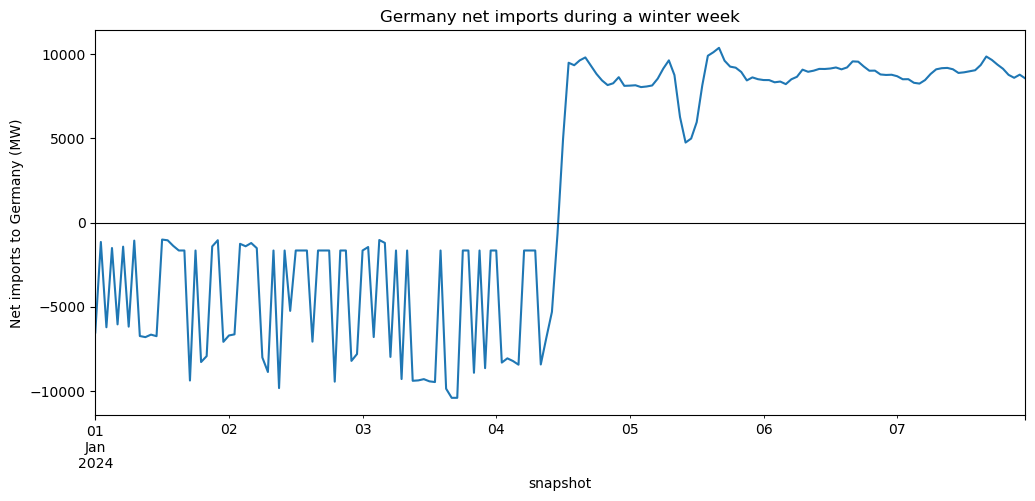

In [89]:
# Germany net imports plot

flows = n_part_d.lines_t.p0.copy()
flows.columns = flows.columns.map(str)

line_table = n_part_d.lines.copy()
line_table.index = line_table.index.map(str)

germany_net_imports = pd.Series(0.0, index=flows.index)

for line_name in line_table.index:
    bus0 = line_table.loc[line_name, "bus0"]
    bus1 = line_table.loc[line_name, "bus1"]

    if line_name not in flows.columns:
        print(f"Skipping {line_name}: not found in lines_t.p0")
        continue

    line_flow = flows.loc[:, line_name]

    if bus0 == "Germany":
        germany_net_imports -= line_flow
    elif bus1 == "Germany":
        germany_net_imports += line_flow

ax = germany_net_imports.loc["2024-01-01":"2024-01-07"].plot(figsize=(12, 5))
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Net imports to Germany (MW)")
ax.set_title("Germany net imports during a winter week")

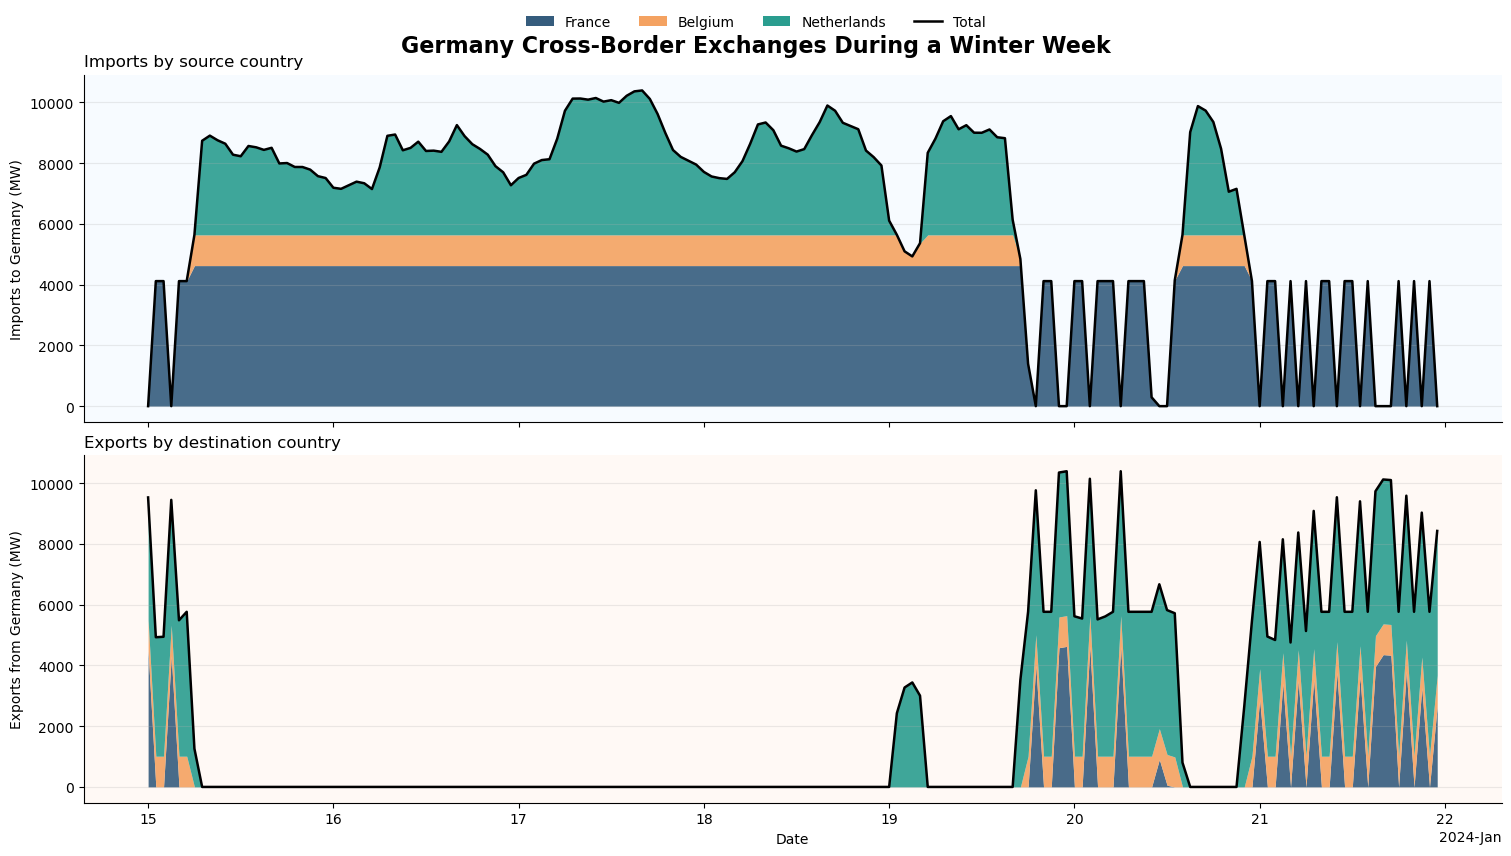

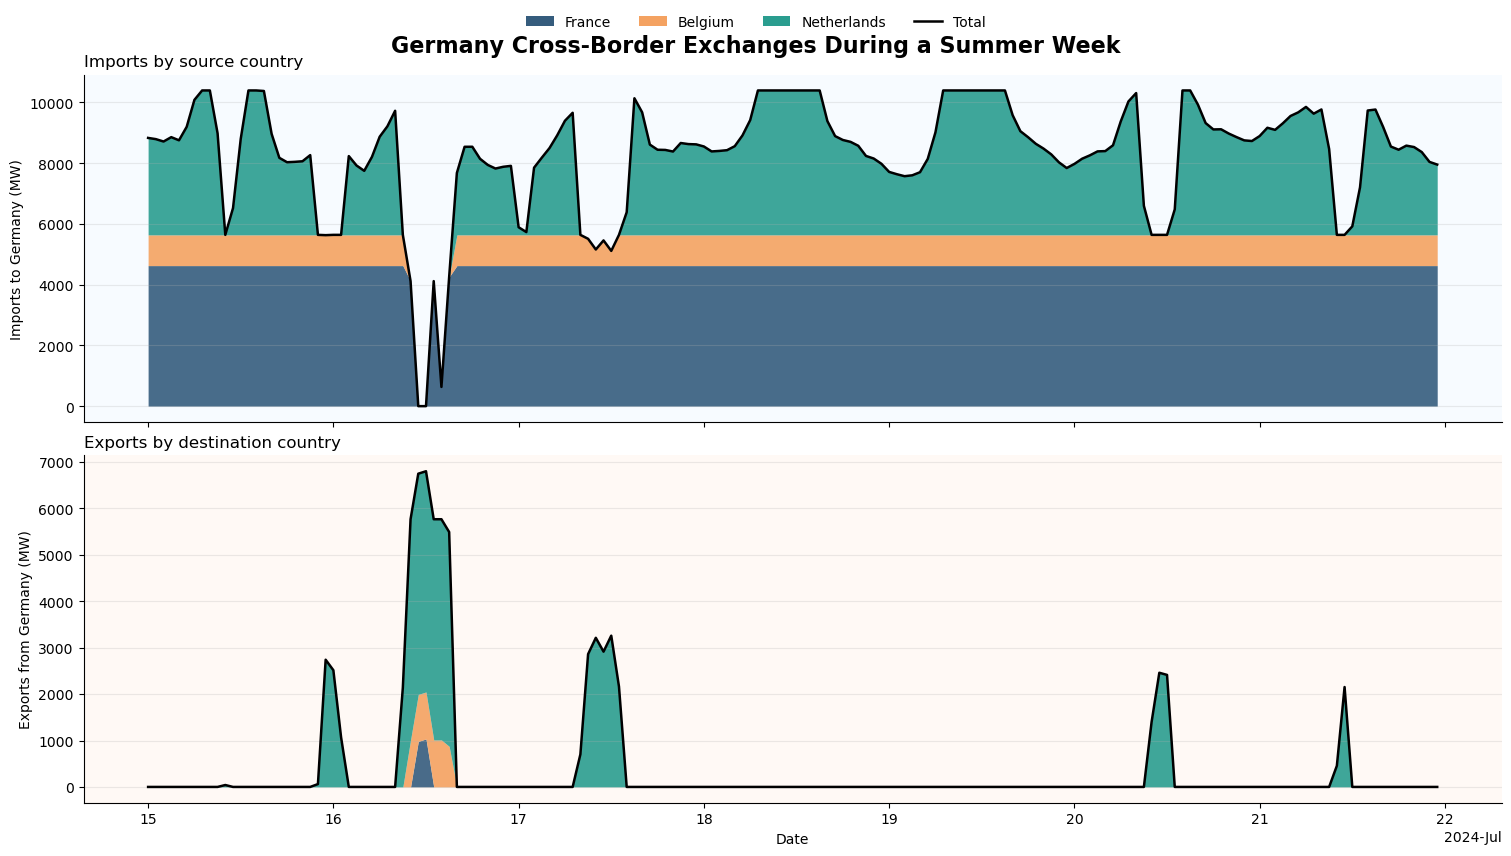

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# --------------------------------------------------
# Build Germany-perspective bilateral exchange table
# positive = import to Germany
# negative = export from Germany
# --------------------------------------------------
flows = n_part_d.lines_t.p0.copy()
flows.columns = flows.columns.map(str)

line_table = n_part_d.lines.copy()
line_table.index = line_table.index.map(str)

germany_trade = {}

for line_name in line_table.index:
    bus0 = str(line_table.loc[line_name, "bus0"])
    bus1 = str(line_table.loc[line_name, "bus1"])

    if line_name not in flows.columns:
        continue

    if "Germany" not in (bus0, bus1):
        continue

    neighbour = bus1 if bus0 == "Germany" else bus0
    line_flow = flows[line_name]

    # PyPSA sign from Germany's perspective
    germany_trade[neighbour] = -line_flow if bus0 == "Germany" else line_flow

de_trade = pd.DataFrame(germany_trade).sort_index()

country_order = [c for c in ["France", "Belgium", "Netherlands"] if c in de_trade.columns]
de_trade = de_trade[country_order]

# --------------------------------------------------
# One color per country, same in imports and exports
# --------------------------------------------------
colors = {
    "France": "#355C7D",
    "Belgium": "#F4A261",
    "Netherlands": "#2A9D8F",
}

def plot_germany_trade_week(df, start, end, title):
    window = df.loc[start:end].copy()

    imports = window.clip(lower=0)
    exports = (-window.clip(upper=0))  # convert exports to positive magnitudes

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(15, 8), sharex=True, constrained_layout=True
    )

    fig.suptitle(title, fontsize=16, fontweight="bold", y=1.02)

    # Subtle backgrounds
    ax1.set_facecolor("#F7FBFF")
    ax2.set_facecolor("#FFF9F5")

    # ---------------- Imports ----------------
    bottom = pd.Series(0.0, index=window.index)
    for country in window.columns:
        ax1.fill_between(
            window.index,
            bottom,
            bottom + imports[country],
            color=colors[country],
            alpha=0.90,
            linewidth=0,
            label=country,
        )
        bottom = bottom + imports[country]

    ax1.plot(
        window.index,
        imports.sum(axis=1),
        color="black",
        linewidth=1.8,
        label="Total imports",
    )
    ax1.set_ylabel("Imports to Germany (MW)")
    ax1.set_title("Imports by source country", loc="left", fontsize=12)
    ax1.grid(axis="y", alpha=0.25)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    # ---------------- Exports ----------------
    bottom = pd.Series(0.0, index=window.index)
    for country in window.columns:
        ax2.fill_between(
            window.index,
            bottom,
            bottom + exports[country],
            color=colors[country],
            alpha=0.90,
            linewidth=0,
            label=country,
        )
        bottom = bottom + exports[country]

    ax2.plot(
        window.index,
        exports.sum(axis=1),
        color="black",
        linewidth=1.8,
        label="Total exports",
    )
    ax2.set_ylabel("Exports from Germany (MW)")
    ax2.set_title("Exports by destination country", loc="left", fontsize=12)
    ax2.grid(axis="y", alpha=0.25)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.set_xlabel("Date")

    # Date formatting
    locator = mdates.DayLocator(interval=1)
    formatter = mdates.ConciseDateFormatter(locator)
    ax2.xaxis.set_major_locator(locator)
    ax2.xaxis.set_major_formatter(formatter)

    # Shared legend
    legend_handles = [Patch(facecolor=colors[c], label=c) for c in window.columns]
    legend_handles += [
        Line2D([0], [0], color="black", lw=1.8, label="Total"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=len(window.columns) + 1,
        frameon=False,
        bbox_to_anchor=(0.5, 1.06),
    )

    plt.show()


# Winter week
plot_germany_trade_week(
    de_trade,
    "2024-01-15",
    "2024-01-21 23:00",
    "Germany Cross-Border Exchanges During a Winter Week"
)

# Summer week
plot_germany_trade_week(
    de_trade,
    "2024-07-15",
    "2024-07-21 23:00",
    "Germany Cross-Border Exchanges During a Summer Week"
)


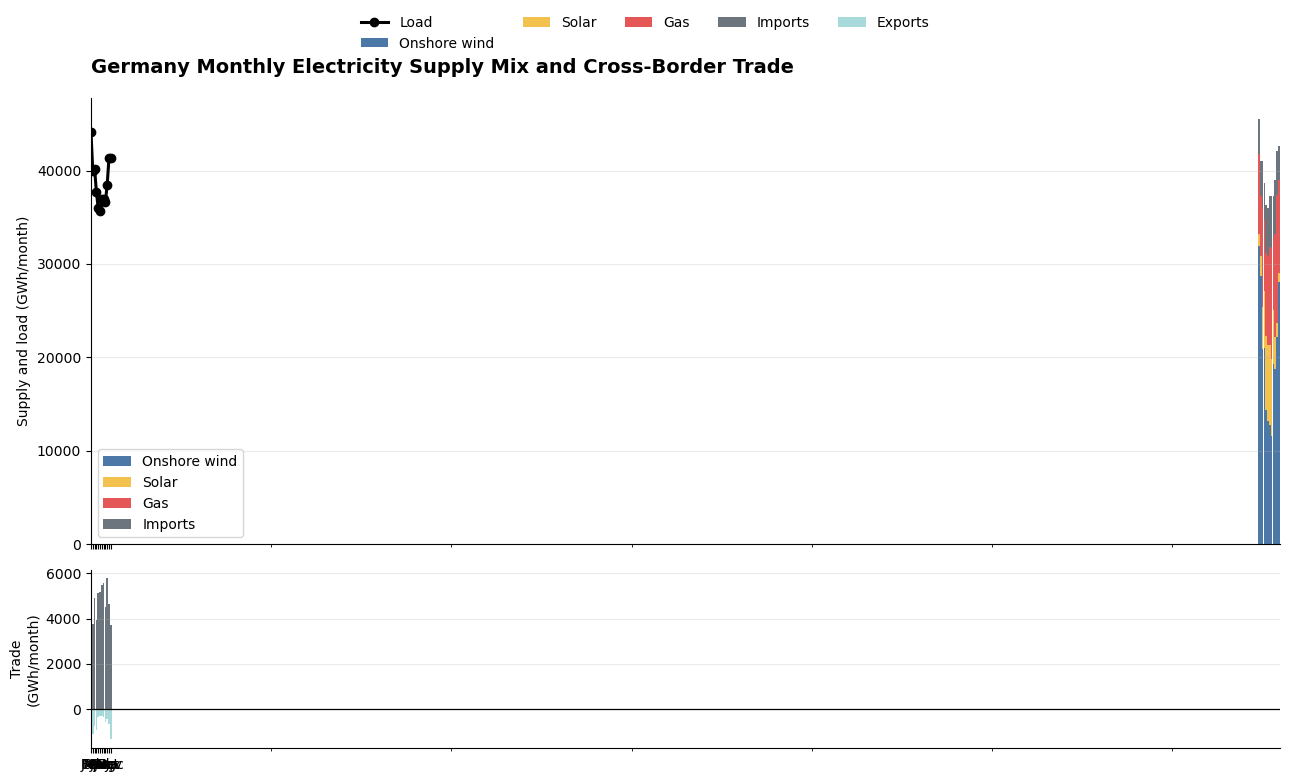

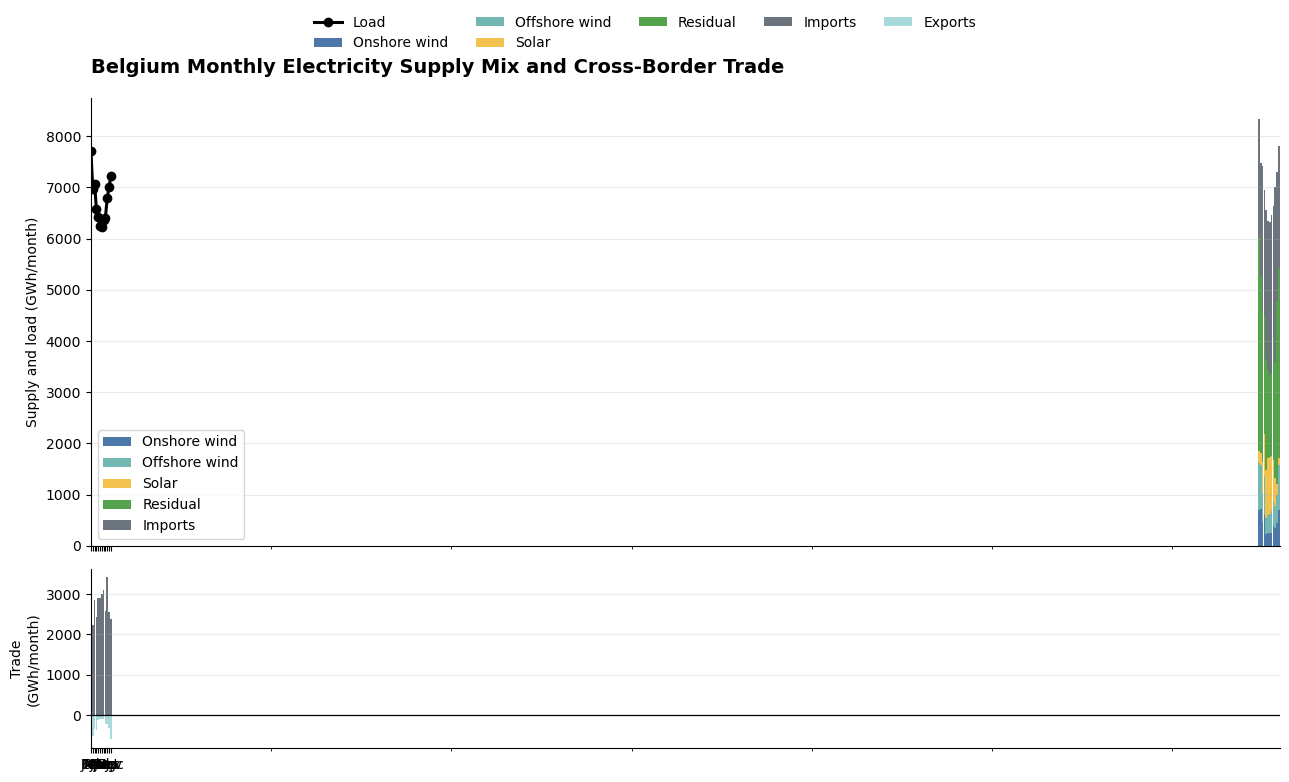

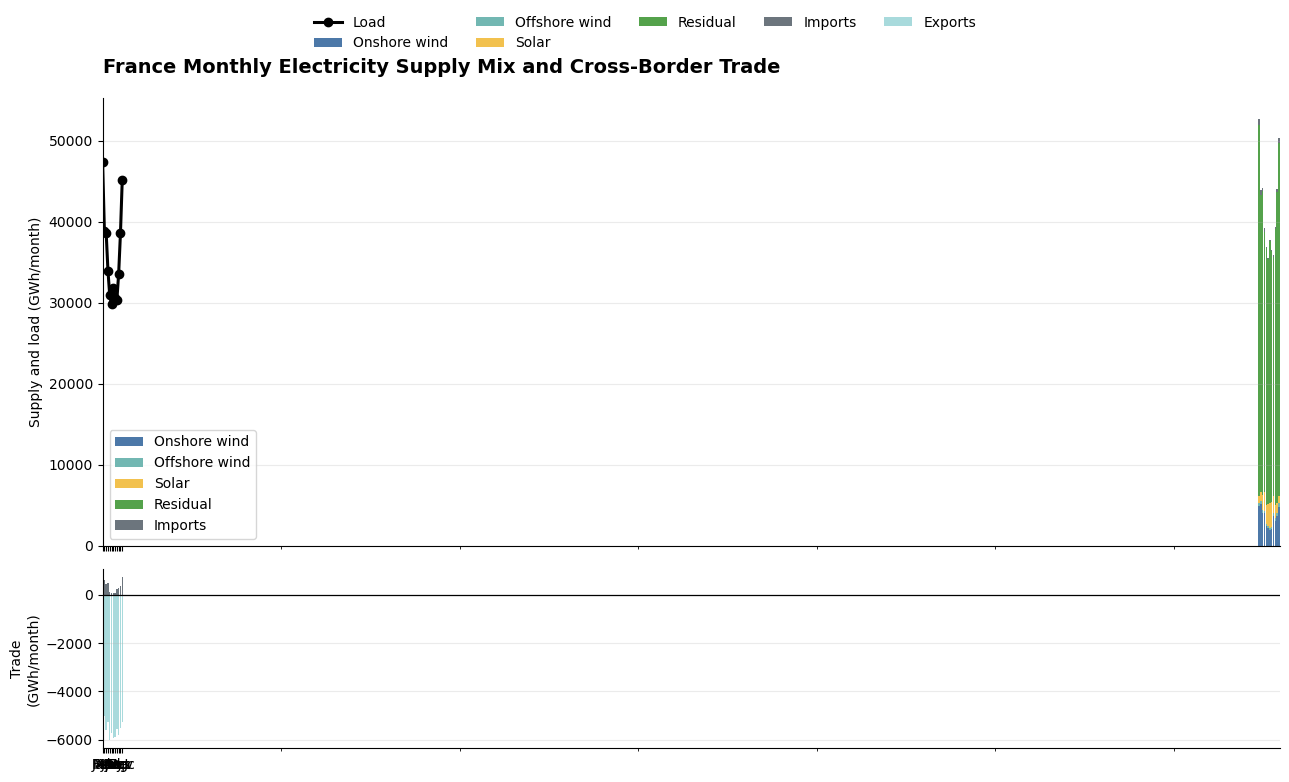

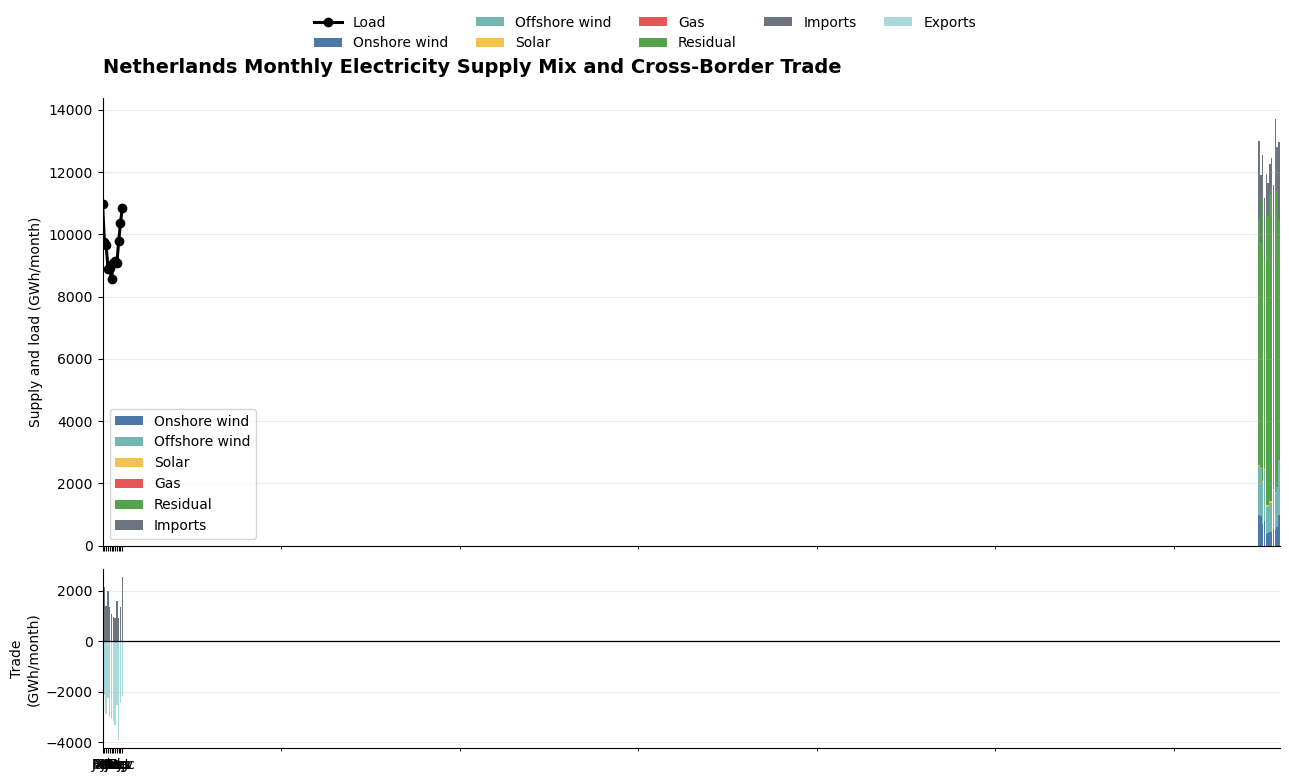

In [100]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------
# Pretty names and colors
# ---------------------------------------------
carrier_labels = {
    "wind_onshore": "Onshore wind",
    "wind_offshore": "Offshore wind",
    "solar": "Solar",
    "gas": "Gas",
    "residual": "Residual",
    "battery_discharge": "Battery discharge",
    "imports": "Imports",
}

colors = {
    "Onshore wind": "#4C78A8",
    "Offshore wind": "#72B7B2",
    "Solar": "#F2C14E",
    "Gas": "#E45756",
    "Residual": "#54A24B",
    "Battery discharge": "#B279A2",
    "Imports": "#6C757D",
}

trade_colors = {
    "Imports": "#6C757D",
    "Exports": "#A8DADC",
}

# ---------------------------------------------
# Build monthly plot for one country
# ---------------------------------------------
def plot_country_monthly_mix_and_trade(network, country):
    start = "2024-01-01"
    end = "2024-12-31 23:00"

    # -------------------------
    # Generator dispatch
    # -------------------------
    gen_p = network.generators_t.p.copy()
    gen_meta = network.generators.copy()

    country_gens = gen_meta.index[gen_meta["bus"] == country]
    dispatch = pd.DataFrame(index=gen_p.index)

    for gen in country_gens:
        carrier = str(gen_meta.loc[gen, "carrier"])
        label = carrier_labels.get(carrier, carrier)
        dispatch[label] = dispatch.get(label, 0) + gen_p[gen]

    # -------------------------
    # Storage dispatch / charge
    # -------------------------
    battery_charge = pd.Series(0.0, index=dispatch.index)

    if not network.storage_units.empty:
        su_meta = network.storage_units.copy()
        country_su = su_meta.index[su_meta["bus"] == country]

        if len(country_su) > 0:
            su_p = network.storage_units_t.p[country_su].sum(axis=1)
            dispatch["Battery discharge"] = su_p.clip(lower=0)
            battery_charge = (-su_p.clip(upper=0))

    # -------------------------
    # Cross-border trade from country perspective
    # positive = import to country
    # negative = export from country
    # -------------------------
    flows = network.lines_t.p0.copy()
    line_table = network.lines.copy()

    net_trade = pd.Series(0.0, index=flows.index)

    for line_name in line_table.index:
        bus0 = str(line_table.loc[line_name, "bus0"])
        bus1 = str(line_table.loc[line_name, "bus1"])
        line_flow = flows[line_name]

        if bus0 == country:
            net_trade -= line_flow
        elif bus1 == country:
            net_trade += line_flow

    imports = net_trade.clip(lower=0)
    exports = (-net_trade.clip(upper=0))

    dispatch["Imports"] = imports

    # -------------------------
    # Load
    # -------------------------
    load_name = network.loads.index[network.loads["bus"] == country][0]
    load = network.loads_t.p[load_name]

    # -------------------------
    # Restrict to 2024
    # -------------------------
    dispatch = dispatch.loc[start:end]
    exports = exports.loc[start:end]
    battery_charge = battery_charge.loc[start:end]
    load = load.loc[start:end]

    # -------------------------
    # Monthly energy in GWh
    # -------------------------
    monthly_supply = dispatch.resample("ME").sum() / 1000
    monthly_exports = exports.resample("ME").sum() / 1000
    monthly_load = load.resample("ME").sum() / 1000
    monthly_charge = battery_charge.resample("ME").sum() / 1000

    monthly_supply = monthly_supply.loc[:, monthly_supply.sum() > 0.1]

    # -------------------------
    # Plot
    # -------------------------
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(13, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [4, 1.6]}
    )

    plot_colors = [colors.get(col, "#999999") for col in monthly_supply.columns]

    monthly_supply.plot(
        kind="bar",
        stacked=True,
        ax=ax1,
        color=plot_colors,
        width=0.82
    )

    x = range(len(monthly_load))

    ax1.plot(
        x,
        monthly_load.values,
        color="black",
        linewidth=2.2,
        marker="o",
        label="Load"
    )

    if monthly_charge.sum() > 0.1:
        ax1.plot(
            x,
            monthly_charge.values,
            color="#8D99AE",
            linewidth=1.8,
            linestyle="--",
            marker="s",
            label="Battery charging"
        )

    ax1.set_title(
        f"{country} Monthly Electricity Supply Mix and Cross-Border Trade",
        loc="left",
        fontsize=14,
        fontweight="bold",
        pad=18
    )
    ax1.set_ylabel("Supply and load (GWh/month)")
    ax1.grid(axis="y", alpha=0.25)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    monthly_imports = monthly_supply["Imports"] if "Imports" in monthly_supply.columns else pd.Series(0.0, index=monthly_supply.index)

    ax2.bar(
        x,
        monthly_imports.values,
        width=0.82,
        color=trade_colors["Imports"],
        label="Imports"
    )
    ax2.bar(
        x,
        -monthly_exports.values,
        width=0.82,
        color=trade_colors["Exports"],
        label="Exports"
    )

    ax2.axhline(0, color="black", linewidth=0.9)
    ax2.set_ylabel("Trade\n(GWh/month)")
    ax2.grid(axis="y", alpha=0.25)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    ax2.set_xticks(list(x))
    ax2.set_xticklabels([ts.strftime("%b") for ts in monthly_supply.index], rotation=0)

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    seen = set()
    handles, labels = [], []
    for h, l in list(zip(handles1, labels1)) + list(zip(handles2, labels2)):
        if l not in seen:
            handles.append(h)
            labels.append(l)
            seen.add(l)

    fig.legend(
        handles,
        labels,
        frameon=False,
        ncol=5,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.98)
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


# ---------------------------------------------
# One plot per country
# ---------------------------------------------
for country in ["Germany", "Belgium", "France", "Netherlands"]:
    plot_country_monthly_mix_and_trade(n_part_d, country)


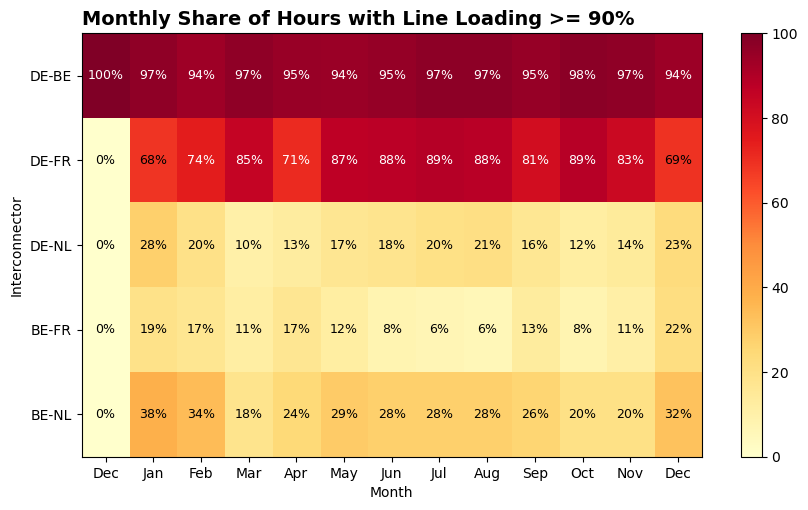

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Line loading
# -------------------------------------------------
flows = n_part_d.lines_t.p0.abs()
line_caps = n_part_d.lines["s_nom"]

line_loading = flows.divide(line_caps, axis=1)  # p.u.
line_loading_pct = 100 * line_loading

# Choose a congestion threshold
threshold = 90  # %
congested = (line_loading_pct >= threshold).astype(int)

# Monthly share of congested hours (%)
monthly_congestion = congested.resample("ME").mean() * 100
monthly_congestion.index = [d.strftime("%b") for d in monthly_congestion.index]

# Optional nicer line labels
monthly_congestion = monthly_congestion.rename(columns={
    "Germany-Belgium": "DE-BE",
    "Germany-France": "DE-FR",
    "Germany-Netherlands": "DE-NL",
    "Belgium-France": "BE-FR",
    "Belgium-Netherlands": "BE-NL",
})

# -------------------------------------------------
# Heatmap
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5.5))

data = monthly_congestion.T.values
im = ax.imshow(data, aspect="auto", cmap="YlOrRd", vmin=0, vmax=100)

ax.set_xticks(np.arange(monthly_congestion.shape[0]))
ax.set_xticklabels(monthly_congestion.index)

ax.set_yticks(np.arange(monthly_congestion.shape[1]))
ax.set_yticklabels(monthly_congestion.columns)

ax.set_title(f"Monthly Share of Hours with Line Loading >= {threshold}%", loc="left", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Interconnector")

# Annotate cells
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        value = data[i, j]
        ax.text(
            j, i, f"{value:.0f}%",
            ha="center", va="center",
            color="black" if value < 70 else "white",
            fontsize=9
        )

cbar = fig.colorbar(im, ax=ax)


# Section E
(Note: this section must be solved with pen and paper. The objective is to replicate the power flows that you obtained for the first time step in your simulation.)

Calculate the incidence matrix and the power transfer distribution factor (PTDF) matrix of the network that you defined in the previous section. Read from your PyPSA model the imbalances in the first time step in every node (i.e. generation - demand). Assuming linearised AC power flows, and the previously determined PTDF matrix, calculate the optimal power flowing through every line and check that it coincides with the modelled results.


In [96]:
# Helper outputs for the pen-and-paper PTDF calculation (after you solved part d)

# t0 = n.snapshots[0]
#
# gen_t0 = n.generators_t.p.loc[t0]
# load_t0 = n.loads_t.p.loc[t0]
#
# injections = gen_t0.groupby(n.generators.bus).sum().reindex(n.buses.index).fillna(0.0)
# withdrawals = load_t0.groupby(n.loads.bus).sum().reindex(n.buses.index).fillna(0.0)
# imbalance = injections - withdrawals
#
# lines = n.lines[["bus0", "bus1", "x", "s_nom"]].copy()
# flows_t0 = n.lines_t.p0.loc[t0]  # flow from bus0 -> bus1
#
# imbalance, lines, flows_t0


In [98]:
# input values needed for pen-and-paper PTDF calculation displayed in a clear way:
t0 = n_part_d.snapshots[1]

gen_t0 = n_part_d.generators_t.p.loc[t0]
load_t0 = n_part_d.loads_t.p.loc[t0]

gen_by_bus = gen_t0.groupby(n_part_d.generators.bus).sum().reindex(n_part_d.buses.index, fill_value=0.0)
load_by_bus = load_t0.groupby(n_part_d.loads.bus).sum().reindex(n_part_d.buses.index, fill_value=0.0)
imbalance = gen_by_bus - load_by_bus

flows_t0 = n_part_d.lines_t.p0.loc[t0]

print("First snapshot:", t0)
print("\nGeneration by bus at t0 (MW):")
print(gen_by_bus)
print("\nLoad by bus at t0 (MW):")
print(load_by_bus)
print("\nNodal imbalance at t0 = generation - load (MW):")
print(imbalance)
print("\nLine flows at t0 (MW):")
print(flows_t0)


First snapshot: 2024-01-01 00:00:00

Generation by bus at t0 (MW):
name
Germany        45333.625
Belgium         9802.800
France         48501.050
Netherlands     5358.100
Name: 2024-01-01 00:00:00, dtype: float64

Load by bus at t0 (MW):
name
Germany        38818.125
Belgium         7335.300
France         51600.000
Netherlands    11242.150
Name: 2024-01-01 00:00:00, dtype: float64

Nodal imbalance at t0 = generation - load (MW):
name
Germany        6515.50
Belgium        2467.50
France        -3098.95
Netherlands   -5884.05
Name: 2024-01-01 00:00:00, dtype: float64

Line flows at t0 (MW):
name
Germany-Belgium        1012.000
Germany-France         2055.475
Germany-Netherlands    3448.025
Belgium-France         1043.475
Belgium-Netherlands    2436.025
Name: 2024-01-01 00:00:00, dtype: float64


In [99]:
# Print predefined transmission line capacities used in the model

print("Interconnector capacities used in the model (MW):")
for line_name, row in n_part_d.lines[["bus0", "bus1", "s_nom"]].iterrows():
    print(f"({row['bus0']!r}, {row['bus1']!r}): {row['s_nom']:.0f}")

Interconnector capacities used in the model (MW):
('Germany', 'Belgium'): 1012
('Germany', 'France'): 4628
('Germany', 'Netherlands'): 5175
('Belgium', 'France'): 5129
('Belgium', 'Netherlands'): 3743
